In [1]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [1]:
##################################################
# Input data directory - /Session_Organized_2. 
##################################################

In [2]:
# my dqm library
import dqm

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import re
import seaborn as sns
from datetime import datetime
from shutil import move
import plotly.express as px
import pytz
import plotly.graph_objects as go



In [4]:
def levels_info_per_participant_session(dir_root_levels_info,levels_info_REORGANIZED):
####################################################################################################
    # For number of files in each session.
    number_files_list = []
    pid_list = []
    session_ID_list = []

####################################################################################################
# 
    json_file_list =[]
    pid_list_file_name = []
    sessionID_list = []
####################################################################################################
    number_of_files_list  = []
    for pid in levels_info_REORGANIZED:
        if pid!=".DS_Store":
            print("pid:======================= ",pid)
            pid_folder = dir_root_levels_info + "/" + pid
            session_folders = [f for f in os.listdir(pid_folder)]
            print("session_folders: ",session_folders)
            for session_folder in session_folders:
                if session_folder!=".DS_Store":
                    session_folder_path = dir_root_levels_info + "/" + pid + "/" + session_folder
                    session_files = [f for f in os.listdir(session_folder_path)]
                    number_files_list.append(len(session_files))
                    pid_list.append(pid)
                    session_ID_list.append(session_folder)
                    print("Number of files in session: ",session_folder, len(session_files))
                for file in session_files:
                    if file!= ".DS_Store" and session_folder!=".DS_Store":
                        full_file_path = dir_root_levels_info + "/" + pid + "/" + session_folder +"/"+file
                        print("file: ",file)
                        
                        json_file_list.append(file)
                        pid_list_file_name.append(pid)
                        sessionID_list.append(session_folder)
                        
                             # Open and read the JSON file
                        with open(full_file_path, 'r') as file:
                            data = json.load(file)
                        print("TimeToCompleteLevel: ",data["TimeToCompleteLevel"])
        #   json_file_list.append(file)
         #               pid_list.append(pid)
          #              sessionID_list.append(session_folder)
    df_with_file_names = pd.DataFrame({"json_file_list":json_file_list,"pid_list":pid_list_file_name,"sessionID_list":sessionID_list})
    df_number_of_files = pd.DataFrame({'number_files_list': number_files_list, 'pid_list': pid_list,'session_id_list':session_ID_list})
    return df_number_of_files,df_with_file_names

            


In [5]:
###########################################################################
# FOR HR DATA:
# 1. Number of files for heart rate data.
# 2. Yeild: 
###########################################################################

########################################## ANALYSE PER SESSION PER PARTICIPANT DATA. ##########################################

def hr_analysis_per_participant_per_session(pid_folders):
    ####################################################################################################
     # Variables for NUMEBR OF FILES metric.
    pid_list = []
    session_id_list = []
    numebr_of_files_session = []
    ####################################################################################################
    # Variables for YEILD metric.
    pid_list_yeild = []
    session_id_list_yeild = []
    filename_list_yeild = []
    yeild_hr_list = []
    ####################################################################################################
    
    ####################################################################################################
    # Variables for HR data files.
    json_file_list = []
    pid_list_file_name = []
    sessionID_list = []
    ####################################################################################################
    HR_df_raw_data = []
    ####################################################################################################
    # Variables for percentage 0s.
    percentage_0s_list = []
    # Variables for percentage_missing.
    percentage_missing_list = []
    snr_hr_list = []
    scr_value_list = []
    for pid in pid_folders:
        if pid ==".DS_Store":
            pass
        else:
            pid_folder = reorganized_root_folder +"/"+ pid
            session_folders = [f for f in os.listdir(pid_folder) if f.endswith('')]
            for session in session_folders:
                if session ==".DS_Store":
                    pass
                else:
                    session_folder_path = pid_folder + "/" +session
                    session_folder_path_files = [f for f in os.listdir(session_folder_path) if f.endswith('')]
                    l1_files = [file for file in session_folder_path_files if '_L1_' in file]
                    print("pid: ",pid,"session ID: ",session, "Number of files in session folder: ",len(session_folder_path_files))
                    pid_list.append(pid)
                    session_id_list.append(session)
                    numebr_of_files_session.append(len(session_folder_path_files))
                   ################################################################################################################################################################################################################################################################################################################################
                    level_files_sorted = sorted(session_folder_path_files, key=lambda x: int(x.split(".")[0].split('_')[-2]))
                    timestamp = int(level_files_sorted[0].split(".")[0].split("_")[-2])
                    SESSION_HR_DF_LIST = []
                    # All files in the following folder /N3/Session_1/.CSV
                    for file in level_files_sorted:
                        json_file_path = session_folder_path  + "/"+ file
                        df_hr = pd.read_csv(json_file_path)
                        
                        #################### Create raw HR data frame. ####################
                        df_hr["Session_ID"] = session
                        df_hr["PID"] = pid

                        # Create one big file for the entire raw data.
                        HR_df_raw_data.append(df_hr)
                        ###################################################################
                        
                        # List of PIDs.
                        pid_list_file_name.append(pid)
                        json_file_list.append(file)
                        sessionID_list.append(session_folder_path.split("/")[-1])
                        
                        # 1. get the percentage 0s metric.
                        percentage_zeros = dqm.percentage_zeros_hr(df_hr)
                        
                        # 2. get the signal to noise ratio.
                        snr_hr_metric = dqm.snr_hr(df_hr)
                        
                        # 3. get the missing data percentage.
                        percentage_missing = dqm.percentage_missing_hr(df_hr)
                        
                        # 4. get sample rate consistency variable.
                        scr_value = dqm.calculate_src(df_hr)
                        
                        scr_value_list.append(scr_value)
                        percentage_0s_list.append(percentage_zeros)
                        
                        snr_hr_list.append(snr_hr_metric)
                        
                        percentage_missing_list.append(percentage_missing)
                        
                        df_hr = df_hr[df_hr['bpm'] != 0]
                        print("df_hr: \n" , df_hr)
                        # to get from "2024-02-22 04:42:43.358" => "04:42:43.358"
                        df_hr['ts_only'] = df_hr["watch_timestamp"].apply(dqm.custom_function)
                        # to get from "04:42:43.358" => "04:42:43"
                        df_hr["ts_seconds"] = df_hr["ts_only"].apply(dqm.format_ts_seconds)
                        # yeild = calcualte_yeild_hr(df_hr,pid,session,file) #calcualte_yeild_hr(df_hr)
                        # print("ts_seconds value_counts(): ", df_hr["ts_seconds"].value_counts().to_dict())
                        # To calcualte SAMPLE RATE: How many samples in one second?===========================
                        dict_sr = df_hr["ts_seconds"].value_counts().to_dict()
                        total_sum = sum(dict_sr.values())
                        # Step 2: Count the number of values
                        num_values = len(dict_sr) # Total number of seconds in the file.
                        

                        if num_values !=0:
                            print("number of seconds in this file: ",num_values)
                            print("RECIEVED Number of samples in this file: ",df_hr.shape[0])
                            print("EXPECTED number of samples: ",num_values*1)
                            yeild = (num_values*1)/df_hr.shape[0]
                            print("pid: ",pid,"session ID: ",session,"filename: ",file)
                            print("Percentage yeild: ",yeild)
                            pid_list_yeild.append(pid)
                            session_id_list_yeild.append(session)
                            filename_list_yeild.append(file)
                            yeild_hr_list.append(yeild)
                            average_sr = total_sum / num_values
                            print("average_sr =======: ",average_sr)

                        else:
                            print("FLAG!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    HR_raw_data = pd.concat(HR_df_raw_data)
    
    # create pandas df from list of lists.
    df_hr_file_name_info = pd.DataFrame({
            "json_file_list_HR":json_file_list,
            "pid_list_file_name_HR":pid_list_file_name,
            "sessionID_list_HR":  sessionID_list })
    
    df_number_files = pd.DataFrame({"pid_list: ":pid_list,"session_id_list":session_id_list,"numebr_of_files_session":numebr_of_files_session})
    
    
    df_hr_yeild = pd.DataFrame({"pid_list_yeild: ":pid_list_yeild,
                                "session_id_list_yeild":session_id_list_yeild,
                                "filename_list_yeild":filename_list_yeild,
                               "yeild_hr_list":yeild_hr_list })
    percentage_0s_df = pd.DataFrame({
        "percentage_0s":percentage_0s_list,
        "sessionID_list":sessionID_list,
        "pid_list_file_name":pid_list_file_name
    })
    percentage_missing_df  = pd.DataFrame({
        "percentage_missing_list":percentage_missing_list,
        "sessionID_list":sessionID_list,
        "pid_list_file_name":pid_list_file_name
    })
    merged_df_all_Features =  pd.DataFrame({
        "percentage_missing_list_hr":percentage_missing_list,
        "percentage_0s_list_HR": percentage_0s_list,
        "snr_hr_list_hr": snr_hr_list,
        "scr_value_list":scr_value_list,
        "sessionID_list":sessionID_list,
        "pid_list_file_name":pid_list_file_name
    })
    
    return df_number_files, df_hr_yeild,HR_raw_data,df_hr_file_name_info,percentage_0s_df,percentage_missing_df,merged_df_all_Features


In [6]:
def per_participant_per_session_acc(reorganized_root_folder_acc,pid_folders_acc):
    ########################################## ANALYSE PER SESSION PER PARTICIPANT DATA. ##########################################
    pid_list = []
    session_id_list = []
    numebr_of_files_session = []
    ####################################################################################################
    # Variables for YEILD metric.
    pid_list_yeild_acc = []
    session_id_list_yeild_acc = []
    filename_list_yeild_acc = []
    yeild_acc_list = []
    ####################################################################################################
    
    # VARIABLES for file info list.
    json_file_list = []
    pid_list_file_name = []
    sessionID_list = []
    
    ACC_df_raw_data =[]
    
    ####################################################################################################
    #### Variables for signal to noise ratio.
    snr_acc_x_list = []
    snr_acc_y_list = []
    snr_acc_z_list = []
    snr_pid_list = []
    snr_sessionID_list =[]
    scr_value_list =[]
    ####################################################################################################
    percentage_missing_acc_list = []
    for pid in pid_folders_acc:
        if pid ==".DS_Store":
            pass
        else:
            pid_folder = reorganized_root_folder_acc +"/"+ pid
            session_folders = [f for f in os.listdir(pid_folder) if f.endswith('')]


            for session in session_folders:
                if session ==".DS_Store":
                    pass
                else:
                    session_folder_path = pid_folder + "/" +session
                    session_folder_path_files = [f for f in os.listdir(session_folder_path) if f.endswith('')]
                    l1_files = [file for file in session_folder_path_files if '_L1_' in file]
                    print("pid: ",pid,"session ID: ",session, "Number of files in session folder: ",len(session_folder_path_files))
                    pid_list.append(pid)
                    session_id_list.append(session)
                    numebr_of_files_session.append(len(session_folder_path_files))
                   ################################################################################################################################################################################################################################################################################################################################
                    level_files_sorted = sorted(session_folder_path_files, key=lambda x: int(x.split(".")[0].split('_')[-2]))
                    print("level_files_sorted: ",level_files_sorted)
                    timestamp = int(level_files_sorted[0].split(".")[0].split("_")[-2])
                    SESSION_HR_DF_LIST = []
                    # All files in the following folder /N3/Session_1/.CSV
                    for file in level_files_sorted:
                        json_file_path = session_folder_path  + "/"+ file

                        df_acc = pd.read_csv(json_file_path)
                        
                        
                      #################### Create raw ACC data frame. ####################
                        df_acc["Session_ID"] = session
                        df_acc["PID"] = pid
                        ACC_df_raw_data.append(df_acc)
                        snr_acc_x,snr_acc_y,snr_acc_z = dqm.snr_acc(df_acc)
                        
                        
                        snr_acc_x_list.append(snr_acc_x)
                        snr_acc_y_list.append(snr_acc_y)
                        snr_acc_z_list.append(snr_acc_z)
                        
                        snr_pid_list.append(pid)
                        snr_sessionID_list.append(session)
                        
                        # Percentage of missing data.
                        percentage_missing_acc = dqm.percentage_missing_imu(df_acc)
                        percentage_missing_acc_list.append(percentage_missing_acc)
                        
                               
                        # 4. get sample rate consistency variable.
                        scr_value = dqm.calculate_src(df_acc)
                        scr_value_list.append(scr_value)
                        
                        
                        # ['x(m/s^2)', 'y(m/s^2)', 'z(m/s^2)', 'internal_ts', 'watch_timestamp',
                        #        'relative_timestamp', 'Session_ID', 'PID', 'ts_only', 'ts_seconds']
                        
                        df_acc['ts_only'] = df_acc["watch_timestamp"].apply(dqm.custom_function)
                        # to get from "04:42:43.358" => "04:42:43"
                        df_acc["ts_seconds"] = df_acc["ts_only"].apply(dqm.format_ts_seconds)
                        # print("ts_seconds value_counts(): ", df_hr["ts_seconds"].value_counts().to_dict())
                        # To calcualte SAMPLE RATE: How many samples in one second?===========================
                        dict_sr_acc = df_acc["ts_seconds"].value_counts().to_dict()
                        print("dict_sr_acc: ",dict_sr_acc)
                        total_seconds_acc = len(dict_sr_acc) # total number of seconds in accelerometer datafile.
                        EXPECTED_SAMPLES = total_seconds_acc * 30 # 30 Hz data is expected # seconds * 30 = expected number of samples.
                        RECIEVED_SAMPLES = df_acc.shape[0]
                        #print("pid: ",pid,"session ID: ",session, "Number of files in session folder: ",len(session_folder_path_files))
                        num_values = len(dict_sr_acc) # Total number of seconds in the file.
                        if num_values !=0:
                            yeild_acc = (RECIEVED_SAMPLES/EXPECTED_SAMPLES)
                            pid_list_yeild_acc.append(pid) 
                            session_id_list_yeild_acc.append(session)
                            filename_list_yeild_acc.append(file)
                            yeild_acc_list.append(yeild_acc)

                        else:
                            print("Flag!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

                        print("total_seconds_acc========================================: ",total_seconds_acc)

                        SESSION_HR_DF_LIST.append(df_acc)
                    SESSION_HR_DF = pd.concat(SESSION_HR_DF_LIST)
                    # Convert the 'timestamp' column to datetime
                    SESSION_HR_DF['timestamp'] = pd.to_datetime(SESSION_HR_DF['watch_timestamp'])
                        
    ACC_raw_data = pd.concat(ACC_df_raw_data)
    df_filenames_acc = pd.DataFrame({
        "json_file_list_acc":json_file_list,
        "pid_list_file_name_acc":pid_list_file_name,
        "sessionID_list_acc":sessionID_list
    })
    df_number_files_acc = pd.DataFrame({"pid_list: ":pid_list,"session_id_list":session_id_list,"numebr_of_files_session":numebr_of_files_session})

    df_acc_yeild = pd.DataFrame({"pid_list_yeild: ":pid_list_yeild_acc,
                                 "session_id_list_yeild":session_id_list_yeild_acc,
                                 "filename_list_yeild":filename_list_yeild_acc,
                                 "yeild_acc_list":yeild_acc_list
                               })
    df_snr_acc = pd.DataFrame({ "snr_acc_x_list":snr_acc_x_list,
                            "snr_acc_y_list":snr_acc_y_list,
                            "snr_acc_z_list":snr_acc_z_list,
                            "pid":snr_pid_list,
                            "SessionID":snr_sessionID_list })
    df_percentage_missing_acc = pd.DataFrame({ "percentage_missing_acc_list":percentage_missing_acc_list,
                            "pid":snr_pid_list,
                            "SessionID":snr_sessionID_list })
    print("len(snr_acc_x_list),len(snr_acc_y_list),len(snr_acc_z_list),len(scr_value_list),len(percentage_missing_acc_list),len(snr_pid_list),len(snr_sessionID_list): \n",
        len(snr_acc_x_list),len(snr_acc_y_list),len(snr_acc_z_list),len(scr_value_list),len(percentage_missing_acc_list),len(snr_pid_list),len(snr_sessionID_list))
    merged_df_all_features_acc = pd.DataFrame({ "snr_acc_x_list":snr_acc_x_list,
                            "snr_acc_y_list":snr_acc_y_list,
                            "snr_acc_z_list":snr_acc_z_list,
                            "scr_value_list":scr_value_list,
                            "percentage_missing_acc_list":percentage_missing_acc_list,
                            "pid":snr_pid_list,
                            "SessionID":snr_sessionID_list })
#     
    return df_number_files_acc, df_acc_yeild,df_filenames_acc,ACC_raw_data,df_snr_acc,df_percentage_missing_acc,merged_df_all_features_acc




In [7]:
def custom_function2(timestamp_string):
    # Make sure timestamp is in string format.
#     timestamp_str = timestamp_string.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
    #print("custom_function timestamp_string: ",timestamp_string.split(" ")[1],"\n")
    return timestamp_string.split(" ")[1]


In [8]:
def per_participant_per_session_gry(reorganized_root_folder_gry,pid_folders_gry):
    ########################################## ANALYSE PER SESSION PER PARTICIPANT DATA. ##########################################
    pid_list = []
    session_id_list = []
    numebr_of_files_session = []
    
    ########################################################################################################################################################################################################
    yeild_gry = [] 
    pid_list_yeild_gry = [] 
    session_id_list_yeild_gry = []
    filename_list_yeild_gry = [] 
    yeild_gry_list = []
    
    ########################################################################################################################################################################################################
    # VARIABLES FOR FILENAME INFORMATION.
    json_file_list = [] 
    pid_list_file_name =[]
    sessionID_list = []
    ########################################################################################################################################################################################################
    # Variables for SNR.
    
    snr_gyr_x_list,snr_gyr_y_list,snr_gyr_z_list = [],[],[]

    snr_pid_list,snr_sessionID_list  = [] ,[]
    percent_missing_gry_list =[]
    scr_value_list =[]
    for pid in pid_folders_gry:
        if pid ==".DS_Store":
            pass
        else:
            pid_folder = reorganized_root_folder_gry +"/"+ pid
            session_folders = [f for f in os.listdir(pid_folder) if f.endswith('')]


            for session in session_folders:
                if session ==".DS_Store":
                    pass
                else:
                    session_folder_path = pid_folder + "/" +session
                    session_folder_path_files = [f for f in os.listdir(session_folder_path) if f.endswith('')]
                    l1_files = [file for file in session_folder_path_files if '_L1_' in file]
                    print("l1_files: ",l1_files)
                    print("pid: ",pid,"session ID: ",session, "Number of files in session folder: ",len(session_folder_path_files))
                    pid_list.append(pid)
                    session_id_list.append(session)
                    numebr_of_files_session.append(len(session_folder_path_files))
                   ################################################################################################################################################################################################################################################################################################################################
                    level_files_sorted = sorted(session_folder_path_files, key=lambda x: int(x.split(".")[0].split('_')[-2]))
                    timestamp = int(level_files_sorted[0].split(".")[0].split("_")[-2])
                    SESSION_HR_DF_LIST = []
                    # All files in the following folder /N3/Session_1/.CSV
                    for file in level_files_sorted:
                        json_file_path = session_folder_path  + "/"+ file
                        df_gry = pd.read_csv(json_file_path)
                        print("df_gry.columns: ",df_gry.columns)
                       # FILE INFO LISTs ============
                       # df_with_file_names
                       # df_hr_file_name_info_HR
                       # df_filenames_acc

                        json_file_list.append(file)
                        
                        pid_list_file_name.append(pid)
                        sessionID_list.append(session_folder_path.split("/")[-1])
                        # ['x(rad)', 'y(rad)', 'z(rad)', 'internal_ts', 'watch_timestamp',
                        #        'relative_timestamp']
                        snr_gyr_x,snr_gyr_y,snr_gyr_z = dqm.snr_gyro(df_gry)
                        percent_missing_gry = dqm.percentage_missing_imu(df_gry)
                        
                        percent_missing_gry_list.append(percent_missing_gry)
                        snr_gyr_x_list.append(snr_gyr_x)
                        snr_gyr_y_list.append(snr_gyr_y)
                        snr_gyr_z_list.append(snr_gyr_z)
                        
                        
                        snr_pid_list.append(pid)
                        snr_sessionID_list.append(session)
                               
                        # 4. get sample rate consistency variable.
                        scr_value = dqm.calculate_src(df_gry)
                        scr_value_list.append(scr_value)

                        df_gry['ts_only'] = df_gry["watch_timestamp"].apply(dqm.custom_function)
                        # to get from "04:42:43.358" => "04:42:43"
                        df_gry["ts_seconds"] = df_gry["ts_only"].apply(dqm.format_ts_seconds)
                        # print("ts_seconds value_counts(): ", df_hr["ts_seconds"].value_counts().to_dict())
                        # To calcualte SAMPLE RATE: How many samples in one second?===========================
                        dict_sr_gry = df_gry["ts_seconds"].value_counts().to_dict()
                        print("dict_sr_gry: ",dict_sr_gry)
                        total_seconds_gry = len(dict_sr_gry) # total number of seconds in accelerometer datafile.
                        EXPECTED_SAMPLES = total_seconds_gry * 30 # 30 Hz data is expected # seconds * 30 = expected number of samples.
                        RECIEVED_SAMPLES = df_gry.shape[0]
                        #print("pid: ",pid,"session ID: ",session, "Number of files in session folder: ",len(session_folder_path_files))
                        num_values = len(dict_sr_gry) # Total number of seconds in the file.
                        if num_values !=0:
                            yeild_gry = (RECIEVED_SAMPLES/EXPECTED_SAMPLES)
                            pid_list_yeild_gry.append(pid) 
                            session_id_list_yeild_gry.append(session)
                            filename_list_yeild_gry.append(file)
                            yeild_gry_list.append(yeild_gry)
                        else:
                            print("Flag!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
                        SESSION_HR_DF_LIST.append(df_gry)
                    SESSION_HR_DF = pd.concat(SESSION_HR_DF_LIST)
                    # Convert the 'timestamp' column to datetime
                    SESSION_HR_DF['timestamp'] = pd.to_datetime(SESSION_HR_DF['watch_timestamp'])

    df_filenames_gry = pd.DataFrame({
        "json_file_list_gry":json_file_list,
        "pid_list_file_name_gry":pid_list_file_name,
        "sessionID_list_gry":sessionID_list })
    
    df_number_files_gry = pd.DataFrame({"pid_list: ":pid_list,"session_id_list":session_id_list,"numebr_of_files_session":numebr_of_files_session})
    df_yeild_gry = pd.DataFrame({"pid_list_yeild_gry: ":pid_list_yeild_gry,
                                 "session_id_list_yeild_gry":session_id_list_yeild_gry,
                                 "filename_list_yeild_gry":filename_list_yeild_gry,
                                "yeild_gry_list": yeild_gry_list
                                })
    
    # pid_list_file_name,sessionID_list,snr_gyr_x_list,snr_gyr_y_list,snr_gyr_z_list.
    merged_gry_features = pd.DataFrame({
        "pid_list_file_name":pid_list_file_name,
        "sessionID_list":sessionID_list,
        "snr_gyr_x_list":snr_gyr_x_list,
        "snr_gyr_y_list":snr_gyr_y_list,
        "snr_gyr_z_list": snr_gyr_z_list,
        "scr_value_list":scr_value_list,
        "percent_missing_gry_list":percent_missing_gry_list
    })
    
    return df_number_files_gry,df_yeild_gry,df_filenames_gry,merged_gry_features








In [9]:
def per_participant_per_session_mouse(reorganized_root_folder_mouse,pid_folders_mouse):
    ########################################## ANALYSE PER SESSION PER PARTICIPANT DATA. ##########################################
    pid_list,session_id_list,numebr_of_files_session = [],[],[]
    
    ####################################################################################################################################
    json_file_list,pid_list_file_name,sessionID_list = [],[],[]

    ####################################################################################################################################
     
    ################################################# FOR MOUSE CSV FILE ###################################################################################
    mouse_csv_df_list = []
    # SNR ratio.
    snr_mouse_x_list ,snr_mouse_y_list = [],[]
    percentage_missing_mouse_list = []
    for pid in pid_folders_mouse:
        if pid ==".DS_Store":
            pass
        else:
            pid_folder = reorganized_root_folder_mouse +"/"+ pid
            session_folders = [f for f in os.listdir(pid_folder) if f.endswith('')]
            for session in session_folders:
                if session ==".DS_Store":
                    pass
                else:
                    session_folder_path = pid_folder + "/" +session
                    session_folder_path_files = [f for f in os.listdir(session_folder_path) if f.endswith('')]
                    l1_files = [file for file in session_folder_path_files if '_L1_' in file]
                    print("l1_files: ",l1_files)
                    print("pid: ",pid,"session ID: ",session, "Number of files in session folder: ",len(session_folder_path_files))
                    pid_list.append(pid)
                    session_id_list.append(session)
                    numebr_of_files_session.append(len(session_folder_path_files))
                   ################################################################################################################################################################################################################################################################################################################################
                    level_files_sorted = sorted(session_folder_path_files, key=lambda x: int(x.split(".")[0].split('_')[-1]))
                    timestamp = int(level_files_sorted[0].split(".")[0].split("_")[-1])
                    SESSION_HR_DF_LIST = []
                    # All files in the following folder /N3/Session_1/.CSV
                    for file in level_files_sorted:
                        print("Mouse file name ========================================",file)
                        print("Session ID: ====",session)
                        json_file_path = session_folder_path  + "/"+ file
                        df_mouse = pd.read_csv(json_file_path)
                        df_mouse["PID"] = pid
                        df_mouse["sessionID"] = session
                        df_mouse["filename"] = file
                        print("df_mouse: ",df_mouse)
                        
                        mouse_csv_df_list.append(df_mouse)
                        snr_mouse_x,snr_mouse_y = dqm.snr_mouse(df_mouse)
                        snr_mouse_x_list.append(snr_mouse_x)
                        snr_mouse_y_list.append(snr_mouse_y)
                        
#                         # 4. get sample rate consistency variable.
#                         scr_value = dqm.calculate_src(df_mouse)
#                         scr_value_list.append(scr_value)
                        
                        percentage_missing_mouse = dqm.percentage_missing_mouse(df_mouse)
                        percentage_missing_mouse_list.append(percentage_missing_mouse)
                        
                        json_file_list.append(file)
                        pid_list_file_name.append(pid)
                        sessionID_list.append(session_folder_path.split("/")[-1])
                                               

                        SESSION_HR_DF_LIST.append(df_mouse)
                    SESSION_HR_DF = pd.concat(SESSION_HR_DF_LIST)
                    print("SESSION_HR_DF: ",SESSION_HR_DF)
    df_filenames_mouse = pd.DataFrame({
        'json_file_list_mouse': json_file_list,
        'pid_list_file_name_mouse':pid_list_file_name,
        'sessionID_list_mouse':sessionID_list
    })
                        
    df_number_files_mouse = pd.DataFrame({"pid_list: ":pid_list,"session_id_list":session_id_list,
                                          "numebr_of_files_session":numebr_of_files_session})

    
    df_mouse_entire = pd.concat(mouse_csv_df_list, ignore_index=True)
    print("len(pid_list),len(sessionID_list),len(snr_mouse_x_list),len(snr_mouse_y_list): ",len(pid_list),len(sessionID_list),len(snr_mouse_x_list),len(snr_mouse_y_list))
    merged_df_dqm_mouse = pd.DataFrame({"pid_list_file_name: ":pid_list_file_name,
                                        "session_id_list":sessionID_list,
                                        "snr_mouse_x_list":snr_mouse_x_list,
                                        "snr_mouse_y_list":snr_mouse_y_list,
                                        "percentage_missing_mouse_list":percentage_missing_mouse_list
                                       })
    
    return df_number_files_mouse,df_filenames_mouse,df_mouse_entire,merged_df_dqm_mouse



In [10]:
dir_root_levels_info = "/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/MindGame-at-home-study-data/Session_Organized_2/level_info"



In [11]:
levels_info_REORGANIZED = [f for f in os.listdir(dir_root_levels_info)]
pid_dropped = ["N13", "N14", "N17", "N19", "N8", "N21","N11","N9","N12","N16","N3"]
# Dropped - N13, N14, N17, N19, N8, N21,N11,N9,N12,N16,N3
# Drop the unwanted strings
dropped_pid_folders_LEVEL_INFO = [item for item in levels_info_REORGANIZED if item not in pid_dropped]
dropped_pid_folders_LEVEL_INFO




['N15',
 'P4',
 'P3',
 'P5',
 'N7',
 '.DS_Store',
 'N6',
 'P7',
 'N18',
 'N20',
 'P6',
 'N10',
 'N4',
 'N5']

In [12]:
df_number_of_files_levels_info,df_with_file_names = levels_info_per_participant_session(dir_root_levels_info,dropped_pid_folders_LEVEL_INFO)



pid:=======================  N15
session_folders:  ['Session_6_2024-07-05_AM', 'Session_7_2024-07-06_AM', 'Session_3_2024-07-03_PM', 'Session_5_2024-07-04_PM', 'Session_2_2024-06-28_PM', 'Session_1_2024-06-19_PM', 'Session_4_2024-07-04_AM', 'Session_8_2024-07-06_PM']
Number of files in session:  Session_6_2024-07-05_AM 25
file:  info_N15_L5_S1_1720153954.json
TimeToCompleteLevel:  0:41
file:  info_N15_L3_S3_1720153802.json
TimeToCompleteLevel:  0:14
file:  info_N15_L7_S2_1720154147.json
TimeToCompleteLevel:  0:20
file:  info_N15_L6_S2_1720154083.json
TimeToCompleteLevel:  0:14
file:  info_N15_L1_S1_1720153680.json
TimeToCompleteLevel:  0:8
file:  info_N15_L7_S1_1720154123.json
TimeToCompleteLevel:  0:21
file:  info_N15_L3_S1_1720153754.json
TimeToCompleteLevel:  0:24
file:  info_N15_L4_S2_1720153846.json
TimeToCompleteLevel:  0:32
file:  info_N15_L4_S3_1720153882.json
TimeToCompleteLevel:  0:20
file:  info_N15_L5_S2_1720153998.json
TimeToCompleteLevel:  0:32
file:  info_N15_L1_S3_17201

TimeToCompleteLevel:  1:2
file:  info_N7_L4_S3_1718816724.json
TimeToCompleteLevel:  0:33
file:  info_N7_L2_S1_1718816455.json
TimeToCompleteLevel:  0:14
file:  info_N7_L3_S1_1718816513.json
TimeToCompleteLevel:  0:32
file:  info_N7_L2_S3_1718816495.json
TimeToCompleteLevel:  0:14
file:  info_N7_L5_S3_1718816901.json
TimeToCompleteLevel:  0:28
Number of files in session:  Session_2_2024-06-18_PM 26
file:  info_N7_L6_S3_1718738930.json
TimeToCompleteLevel:  0:26
file:  info_N7_L1_S1_1718737968.json
TimeToCompleteLevel:  0:13
file:  info_N7_L5_S3_1718738789.json
TimeToCompleteLevel:  0:33
file:  info_N7_L1_S3_1718738108.json
TimeToCompleteLevel:  0:14
file:  info_N7_L2_S3_1718738282.json
TimeToCompleteLevel:  0:15
file:  info_N7_L7_S2_1718739007.json
TimeToCompleteLevel:  0:25
file:  info_N7_L6_S1_1718738870.json
TimeToCompleteLevel:  0:32
file:  info_N7_L3_S1_1718738300.json
TimeToCompleteLevel:  0:29
file:  info_N7_L3_S3_1718738400.json
TimeToCompleteLevel:  0:18
file:  info_N7_L6_S2_1

TimeToCompleteLevel:  0:20
file:  info_P7_L7_S2_1728663164.json
TimeToCompleteLevel:  0:17
file:  info_P7_L3_S2_1728662822.json
TimeToCompleteLevel:  0:18
file:  info_P7_L9_S1_1728663290.json
TimeToCompleteLevel:  0:18
file:  info_P7_L3_S1_1728662796.json
TimeToCompleteLevel:  0:22
file:  info_P7_L2_S3_1728662125.json
TimeToCompleteLevel:  0:9
file:  info_P7_L4_S3_1728662934.json
TimeToCompleteLevel:  0:22
file:  info_P7_L1_S3_1728662729.json
TimeToCompleteLevel:  0:13
file:  info_P7_L3_S3_1728662843.json
TimeToCompleteLevel:  0:13
file:  info_P7_L4_S2_1728662895.json
TimeToCompleteLevel:  0:36
file:  info_P7_L2_S2_1728662762.json
TimeToCompleteLevel:  0:18
file:  info_P7_L5_S1_1728662959.json
TimeToCompleteLevel:  0:43
file:  info_P7_L5_S1_1728662298.json
TimeToCompleteLevel:  0:47
file:  info_P7_L3_S1_1728662138.json
TimeToCompleteLevel:  0:22
file:  info_P7_L5_S2_1728663005.json
TimeToCompleteLevel:  0:30
file:  info_P7_L5_S3_1728663038.json
TimeToCompleteLevel:  0:26
file:  info_P7

Number of files in session:  Session_7_2024-06-23_PM 4
file:  info_N10_L3_S3_1719170446.json
TimeToCompleteLevel:  0:21
file:  info_N10_L3_S1_1719170353.json
TimeToCompleteLevel:  0:28
file:  info_N10_L3_S2_1719170385.json
TimeToCompleteLevel:  0:19
file:  info_N10_L4_S1_1719170469.json
TimeToCompleteLevel:  0:35
Number of files in session:  Session_4_2024-06-22_AM 22
file:  info_N10_L9_S2_1719037442.json
TimeToCompleteLevel:  0:49
file:  info_N10_L1_S2_1719037537.json
TimeToCompleteLevel:  0:12
file:  info_N10_L6_S1_1719037146.json
TimeToCompleteLevel:  0:33
file:  info_N10_L6_S2_1719037181.json
TimeToCompleteLevel:  0:18
file:  info_N10_L2_S2_1719037583.json
TimeToCompleteLevel:  0:20
file:  info_N10_L2_S1_1719037569.json
TimeToCompleteLevel:  0:12
file:  info_N10_L3_S3_1719037677.json
TimeToCompleteLevel:  0:18
file:  info_N10_L3_S2_1719037650.json
TimeToCompleteLevel:  0:24
file:  info_N10_L7_S3_1719037280.json
TimeToCompleteLevel:  0:26
file:  info_N10_L8_S2_1719037353.json
TimeTo

In [13]:
reorganized_root_folder = "/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/MindGame-at-home-study-data/Session_Organized_2/heartrate_data"

pid_folders = [f for f in os.listdir(reorganized_root_folder) if f.endswith('')]
# pid_folders
pid_dropped = ["N13", "N14", "N17", "N19", "N8", "N21","N11","N9","N12","N16","N3"]
# Dropped - N13, N14, N17, N19, N8, N21,N11,N9,N12,N16,N3
# Drop the unwanted strings

dropped_pid_folders_hr = [item for item in pid_folders if item not in pid_dropped]

print("dropped_pid_folders_hr: ",dropped_pid_folders_hr)


dropped_pid_folders_hr:  ['N15', 'P4', 'P3', 'P5', 'N7', '.DS_Store', 'N6', 'P7', 'N18', 'N20', 'P6', 'N10', 'N4', 'N5']


In [15]:
df_number_files_hr, df_hr_yeild,HR_raw_data,df_hr_file_name_info_HR,percentage_0s_df_hr,percentage_missing_df,merged_df_all_Features = hr_analysis_per_participant_per_session(dropped_pid_folders_hr) 





pid:  N15 session ID:  Session_9_2024-07-06_PM Number of files in session folder:  26
start_time,end_time:  2024-07-06 18:32:34.732000 2024-07-06 18:32:41.740000
df:  8 len(full_time_index):  8
Percentage of missing data:  0.0


TypeError: calculate_src() missing 1 required positional argument: 'timestamp_column'

In [16]:
#merged_df_all_Features.to_csv("/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/DataAnalysis_Files/DQM_Feature_Tables/DQM_feature_table_heartrate.csv",index=0)


In [17]:
# dt = datetime(2024, 7, 6, 18, 32, 34, 732000)
# dt
# /Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/MindGame-at-home-study-data/Session_Organized_2/heartrate_data/N15/Session_2_2024-06-28_PM/watch_N15_L1_S3_1719593813_heartrate.csv
# ---------------------------------------------------------------------------
# ZeroDivisionError                         Traceback (most recent call last)
# /var/folders/d3/mwqwbw3x0b30c22zykpzcrww0000gn/T/ipykernel_27551/1076882455.py in <module>
# ----> 1 df_number_files_hr, df_hr_yeild,HR_raw_data,df_hr_file_name_info_HR,percentage_0s_df_hr,percentage_missing_df,merged_df_all_Features = hr_analysis_per_participant_per_session(dropped_pid_folders_hr)
#       2 
#       3 
#       4 

# /var/folders/d3/mwqwbw3x0b30c22zykpzcrww0000gn/T/ipykernel_27551/2367810342.py in hr_analysis_per_participant_per_session(pid_folders)
#      77 
#      78                         # 2. get the signal to noise ratio.
# ---> 79                         snr_hr_metric = dqm.snr_hr(df_hr)
#      80 
#      81                         # 3. get the missing data percentage.

# ~/opt/anaconda3/envs/carehub/lib/python3.7/site-packages/dqm/__init__.py in snr_hr(df_hr)
#      46 
#      47 def snr_hr(df_hr):
# ---> 48     return df_hr["bpm"].mean()/df_hr["bpm"].std()
#      49 
#      50 def percentage_missing_hr(df):

# ZeroDivisionError: float division by zero


In [18]:
reorganized_root_folder_acc = "/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/MindGame-at-home-study-data/Session_Organized_2/accelerometer_data"

pid_folders_acc = [f for f in os.listdir(reorganized_root_folder_acc) if f.endswith('')]


pid_dropped = ["N13", "N14", "N17", "N19", "N8", "N21","N11","N9","N12","N16","N3"]
# Dropped - N13, N14, N17, N19, N8, N21,N11,N9,N12,N16,N3
# Drop the unwanted strings
dropped_pid_folders_ACC = [item for item in pid_folders_acc if item not in pid_dropped]
dropped_pid_folders_ACC

['N15',
 'P4',
 'P3',
 'P5',
 'N7',
 '.DS_Store',
 'N6',
 'P7',
 'N18',
 'N20',
 'P6',
 'N10',
 'N4',
 'N5']

In [19]:

df_number_files_acc, df_acc_yeild,df_filenames_acc,ACC_raw_data,df_snr_acc,df_percentage_missing_acc,merged_df_all_features_acc = per_participant_per_session_acc(reorganized_root_folder_acc,dropped_pid_folders_ACC)
result_acc = df_acc_yeild.groupby(['pid_list_yeild: ', 'session_id_list_yeild'])['yeild_acc_list'].mean()
pid_average_acc_yeild = result_acc.groupby(['pid_list_yeild: ']).mean()


pid:  N15 session ID:  Session_9_2024-07-06_PM Number of files in session folder:  26
level_files_sorted:  ['watch_N15_L1_S1_1720305155_accelerometer.csv', 'watch_N15_L1_S2_1720305166_accelerometer.csv', 'watch_N15_L1_S3_1720305178_accelerometer.csv', 'watch_N15_L2_S1_1720305192_accelerometer.csv', 'watch_N15_L2_S2_1720305237_accelerometer.csv', 'watch_N15_L2_S3_1720305250_accelerometer.csv', 'watch_N15_L3_S1_1720305261_accelerometer.csv', 'watch_N15_L3_S2_1720305283_accelerometer.csv', 'watch_N15_L3_S3_1720305302_accelerometer.csv', 'watch_N15_L4_S1_1720305316_accelerometer.csv', 'watch_N15_L4_S2_1720305345_accelerometer.csv', 'watch_N15_L4_S3_1720305382_accelerometer.csv', 'watch_N15_L5_S1_1720305403_accelerometer.csv', 'watch_N15_L5_S2_1720305448_accelerometer.csv', 'watch_N15_L5_S3_1720305477_accelerometer.csv', 'watch_N15_L6_S1_1720305502_accelerometer.csv', 'watch_N15_L6_S2_1720305527_accelerometer.csv', 'watch_N15_L6_S3_1720305546_accelerometer.csv', 'watch_N15_L7_S1_1720305568_

TypeError: calculate_src() missing 1 required positional argument: 'timestamp_column'

In [20]:

ACC_raw_data

NameError: name 'ACC_raw_data' is not defined

In [21]:
df_snr_acc["pid"].unique()

NameError: name 'df_snr_acc' is not defined

In [22]:
reorganized_root_folder_gry = "/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/MindGame-at-home-study-data/Session_Organized_2/gyroscope_data"

pid_folders_gry = [f for f in os.listdir(reorganized_root_folder_gry) if f.endswith('')]


pid_dropped = ["N13", "N14", "N17", "N19", "N8", "N21","N11","N9","N12","N16","N3"]
# Dropped - N13, N14, N17, N19, N8, N21,N11,N9,N12,N16,N3
# Drop the unwanted strings
dropped_pid_folders_GRY = [item for item in pid_folders_gry if item not in pid_dropped]
dropped_pid_folders_GRY



['N15',
 'P4',
 'P3',
 'P5',
 'N7',
 '.DS_Store',
 'N6',
 'P7',
 'N18',
 'N20',
 'P6',
 'N10',
 'N4',
 'N5']

In [23]:
df_number_files_gry, df_yeild_gry,df_filenames_gry,merged_gyro_dqm_feature = per_participant_per_session_gry(reorganized_root_folder_gry,dropped_pid_folders_GRY)


l1_files:  ['watch_N15_L1_S2_1720305166_gyroscope.csv', 'watch_N15_L1_S3_1720305178_gyroscope.csv', 'watch_N15_L1_S1_1720305155_gyroscope.csv']
pid:  N15 session ID:  Session_9_2024-07-06_PM Number of files in session folder:  26
df_gry.columns:  Index(['x(rad)', 'y(rad)', 'z(rad)', 'internal_ts', 'watch_timestamp',
       'relative_timestamp'],
      dtype='object')
start_time,end_time:  2024-07-06 18:32:34.112000 2024-07-06 18:32:42.652000
df:  232 len(full_time_index):  257
Percentage of missing data:  9.72762645914397


TypeError: calculate_src() missing 1 required positional argument: 'timestamp_column'

In [24]:
merged_gyro_dqm_feature

NameError: name 'merged_gyro_dqm_feature' is not defined

In [25]:
# merged_gyro_dqm_feature.to_csv("/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/DataAnalysis_Files/DQM_Feature_Tables/DQM_feature_table_gyro.csv",index=0)


In [26]:
reorganized_root_folder_mouse = "/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/MindGame-at-home-study-data/Session_Organized_2/mouse_data"


pid_folders_mouse = [f for f in os.listdir(reorganized_root_folder_mouse) if f.endswith('')]



pid_dropped = ["N13", "N14", "N17", "N19", "N8", "N21","N11","N9","N12","N16","N3"]
# Dropped - N13, N14, N17, N19, N8, N21,N11,N9,N12,N16,N3
# Drop the unwanted strings
dropped_pid_folders_MOUSE = [item for item in pid_folders_mouse if item not in pid_dropped]
dropped_pid_folders_MOUSE




['N15',
 'P4',
 'P3',
 'P5',
 'N7',
 '.DS_Store',
 'N6',
 'P7',
 'N18',
 'N20',
 'P6',
 'N10',
 'N4',
 'N5']

In [27]:
df_number_files_mouse,df_filenames_mouse,df_mouse_entire,merged_df_dqm_mouse  = per_participant_per_session_mouse(reorganized_root_folder_mouse,dropped_pid_folders_MOUSE)

# 22:16:16:179
# ParserError: Unknown string format: 00:28:00:092


l1_files:  ['mouse_N15_L1_S3_1720153703.csv', 'mouse_N15_L1_S1_1720153680.csv', 'mouse_N15_L1_S2_1720153690.csv']
pid:  N15 session ID:  Session_6_2024-07-05_AM Number of files in session folder:  25
Mouse file name ======================================== mouse_N15_L1_S1_1720153680.csv
Session ID: ==== Session_6_2024-07-05_AM
df_mouse:         x    y     timestamp           shape      x(px/s^2)      y(px/s^2)  \
0   1170  922  00:28:00:092             NaN              0              0   
1   1160  870  00:28:00:365             NaN            -74            -82   
2    526  542  00:28:00:565             NaN          -1456          -1844   
3    364  203  00:28:00:765             NaN           -230           -679   
4    348   40  00:28:00:965             NaN            153           -388   
5    608  197  00:28:01:165          Square           7663           4271   
6   1383  584  00:28:01:365          Square             77             97   
7   1373  578  00:28:01:498   END_OF_STROKE 

df_mouse:          x    y     timestamp                 shape      x(px/s^2)  \
0     962  295  00:35:23:414                   NaN              0   
1     958  297  00:35:23:692                   NaN            -18   
2     777  325  00:35:23:892                   NaN          -1515   
3     505  363  00:35:24:092                   NaN           -793   
4     365  362  00:35:24:292                   NaN           -721   
..    ...  ...           ...                   ...            ...   
116   184   90  00:35:44:041                   NaN           -230   
117   154   85  00:35:44:341  Equilateral Triangle             21   
118  1203  519  00:35:44:541  Equilateral Triangle           2912   
119  1539  683  00:35:44:795  Equilateral Triangle              0   
120  1539  683  00:35:44:796         END_OF_STROKE  END_OF_STROKE   

         y(px/s^2)  PID                sessionID  \
0                0  N15  Session_6_2024-07-05_AM   
1                6  N15  Session_6_2024-07-05_AM   
2   

df_mouse:          x    y     timestamp           shape      x(px/s^2)      y(px/s^2)  \
0     932  290  01:12:20:481             NaN              0              0   
1     932  292  01:12:20:766             NaN              0              5   
2     672  298  01:12:20:966             NaN          -2813           -731   
3     397  295  01:12:21:166             NaN          -1442            274   
4     177  252  01:12:21:366             NaN          -1082           -548   
..    ...  ...           ...             ...            ...            ...   
248   300  424  01:13:04:198             NaN           -865           -548   
249   184  410  01:13:04:398             NaN              0             91   
250   508  394  01:13:04:598  Purple Diamond           8366           -274   
251  1222  362  01:13:04:831  Purple Diamond              0              0   
252  1216  349  01:13:04:957   END_OF_STROKE  END_OF_STROKE  END_OF_STROKE   

     PID                sessionID                   

df_mouse:          x    y     timestamp           shape      x(px/s^2)      y(px/s^2)  \
0     920  287  15:44:57:776             NaN              0              0   
1    1214  475  15:44:57:980             NaN           1875           1005   
2    1231  485  15:44:58:246             NaN             -8              0   
3     646  343  15:44:58:446             NaN           -690           -388   
4     342  207  15:44:58:647             NaN           -793           -548   
..    ...  ...           ...             ...            ...            ...   
118   135  405  15:45:18:613             NaN            721            457   
119   195  429  15:45:18:829  Purple Diamond             89             37   
120  1325  871  15:45:19:029  Purple Diamond            153             97   
121  1274  907  15:45:19:229  Purple Diamond           -460            194   
122  1229  904  15:45:19:502   END_OF_STROKE  END_OF_STROKE  END_OF_STROKE   

     PID                sessionID                   

df_mouse:         x    y     timestamp           shape      x(px/s^2)      y(px/s^2)  \
0    937  295  12:40:03:498             NaN              0              0   
1    932  297  12:40:03:786             NaN            -17              5   
2    634  242  12:40:04:002             NaN          -2957           -822   
3    352  224  12:40:04:202             NaN          -1686            582   
4    318   90  12:40:04:485             NaN              0             27   
..   ...  ...           ...             ...            ...            ...   
82   270  679  12:40:19:335             NaN           -613          -1165   
83   125  599  12:40:19:552             NaN            -25              0   
84   159  592  12:40:19:757  Right Triangle           1393            -71   
85  1273  526  12:40:19:969  Right Triangle           2308              0   
86  1323  517  12:40:20:264   END_OF_STROKE  END_OF_STROKE  END_OF_STROKE   

    PID                sessionID                        filename

...

df_mouse:         x    y     timestamp           shape      x(px/s^2)      y(px/s^2) PID  \
0    545  452  21:42:56:278             NaN              0              0  N5   
1    626  899  21:42:56:485             NaN            789           3234  N5   
2    780  940  21:42:56:879             NaN            391            104  N5   
3    974  579  21:42:57:146             NaN            118              0  N5   
4    958  549  21:42:57:378             NaN          -1207             59  N5   
..   ...  ...           ...             ...            ...            ...  ..   
234  260  629  21:43:43:108             NaN            -40            296  N5   
235  290  602  21:43:43:311  Yellow Diamond            144           -135  N5   
236  679  282  21:43:43:513  Yellow Diamond           1472          -1531  N5   
237  730  145  21:43:43:742  Yellow Diamond            241           -947  N5   
238  850   38  21:43:44:010   END_OF_STROKE  END_OF_STROKE  END_OF_STROKE  N5   

                

df_mouse:         x    y     timestamp                 shape      x(px/s^2)  \
0    641  370  12:51:39:904                   NaN              0   
1    645  420  12:51:40:111                   NaN              0   
2    638  411  12:51:40:326                   NaN            -44   
3    383  155  12:51:40:759                   NaN             -5   
4    267  204  12:51:40:959                   NaN            -78   
..   ...  ...           ...                   ...            ...   
126  805  374  12:52:04:738                   NaN              0   
127  819  348  12:52:04:954                   NaN             78   
128  837  286  12:52:05:154  Equilateral Triangle            313   
129  850  190  12:52:05:396  Equilateral Triangle              0   
130  861  235  12:52:05:558         END_OF_STROKE  END_OF_STROKE   

         y(px/s^2) PID                sessionID                       filename  
0                0  N5  Session_1_2024-05-29_PM  mouse_N5_L4_S3_1717001499.csv  
1         

df_mouse:         x    y     timestamp                 shape      x(px/s^2)  \
0    572  397  11:41:41:304                   NaN              0   
1    547  381  11:41:41:505                   NaN           -156   
2    509  309  11:41:41:721                   NaN            -78   
3    416   61  11:41:41:921                   NaN             78   
4    320   24  11:41:42:121                   NaN           -508   
..   ...  ...           ...                   ...            ...   
181   98   53  11:42:14:691                   NaN              0   
182  258  381  11:42:14:892  Equilateral Triangle           1094   
183  531  604  11:42:15:092  Equilateral Triangle           1406   
184  627  606  11:42:15:308  Equilateral Triangle            156   
185  584  571  11:42:15:401         END_OF_STROKE  END_OF_STROKE   

         y(px/s^2) PID                sessionID                       filename  
0                0  N5  Session_6_2024-06-13_AM  mouse_N5_L5_S2_1718293301.csv  
1         

df_mouse:         x    y     timestamp           shape      x(px/s^2)      y(px/s^2) PID  \
0    590  338  19:11:30:545             NaN              0              0  N5   
1    576  120  19:11:30:755             NaN            -83          -1342  N5   
2    513   -1  19:11:31:221             NaN            -15              0  N5   
3     56  114  19:11:31:421             NaN            -78            574  N5   
4    268  442  19:11:31:637             NaN            781           1838  N5   
..   ...  ...           ...             ...            ...            ...  ..   
221  114  590  19:12:15:215             NaN            -39              0  N5   
222  705  758  19:12:15:431  Right Triangle           2109            574  N5   
223  887  801  19:12:15:631  Right Triangle            469            230  N5   
224  988  833  19:12:15:831  Right Triangle            313              0  N5   
225  988  834  19:12:15:858   END_OF_STROKE  END_OF_STROKE  END_OF_STROKE  N5   

                

len(pid_list),len(sessionID_list),len(snr_mouse_x_list),len(snr_mouse_y_list):  133 2427 2427 2427


In [28]:
# merged_df_dqm_mouse.to_csv("/Users/shehjarsadhu/Desktop/UniversityOfRhodeIsland/Graduate/WBL/Project_MindGame/DATASET/DataAnalysis_Files/DQM_Feature_Tables/mouse_DQM_table.csv",index=0)
# merged_df_dqm_mouse
df_mouse_entire

,x,y,timestamp,shape,x(px/s^2),y(px/s^2),PID,sessionID,filename
0,1170,922,1900-01-01 00:28:00.092,NaN,0,0,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
1,1160,870,1900-01-01 00:28:00.365,NaN,-74,-82,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
2,526,542,1900-01-01 00:28:00.565,NaN,-1456,-1844,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
3,364,203,1900-01-01 00:28:00.765,NaN,-230,-679,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
4,348,40,1900-01-01 00:28:00.965,NaN,153,-388,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
...,...,...,...,...,...,...,...,...,...
344512,122,96,1900-01-01 19:17:12.714,Equilateral Triangle,34,25,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344513,709,268,1900-01-01 19:17:12.919,Equilateral Triangle,409,0,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344514,805,247,1900-01-01 19:17:13.130,Equilateral Triangle,20,-30,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344515,850,235,1900-01-01 19:17:13.339,Equilateral Triangle,-1250,230,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv


In [29]:
###### Rename all columns.
df_number_of_files_levels_info.rename(columns={
    "number_files_list": "number_files_list_level_info", 
    "pid_list": "pid_list",
    "session_id_list":"session_id_list" ,
    "int_session":"int_session",

}, inplace=True)
df_number_files_hr.rename(columns={
    'pid_list: ': "pid_list", 
    'session_id_list': "session_id_list",
    'numebr_of_files_session':"number_files_list_hr" ,
    'int_session':"int_session",

}, inplace=True)

df_number_files_acc.rename(columns={
    'pid_list: ': "pid_list", 
    'session_id_list': "session_id_list",
    'numebr_of_files_session':"number_files_list_acc" ,
    'int_session':"int_session",

}, inplace=True)
df_number_files_gry.rename(columns={
    'pid_list: ': "pid_list", 
    'session_id_list': "session_id_list",
    'numebr_of_files_session':"number_files_list_gry" ,
    'int_session':"int_session",

}, inplace=True)

df_number_files_mouse.rename(columns={
    'pid_list: ': "pid_list", 
    'session_id_list': "session_id_list",
    'numebr_of_files_session':"number_files_list_mouse" ,
    'int_session':"int_session",

}, inplace=True)

NameError: name 'df_number_files_hr' is not defined

In [30]:
# Merge the DataFrames sequentially

# 1. df_number_of_files_levels_info,
# 2. df_number_files_hr,
# 3. df_number_files_acc,
# 4. df_number_files_gry,
# 5. df_number_files_mouse
merged_df = df_number_of_files_levels_info.merge(df_number_files_hr, on=["pid_list", "session_id_list"], how="inner")  # Inner merge on first two
merged_df = merged_df.merge(df_number_files_acc, on=["pid_list", "session_id_list"], how="inner")  # Merge the result with df3
merged_df = merged_df.merge(df_number_files_gry, on=["pid_list", "session_id_list"], how="inner")  # Finally merge with df4
merged_df = merged_df.merge(df_number_files_mouse, on=["pid_list", "session_id_list"], how="inner")  # Finally merge with df4



NameError: name 'df_number_files_hr' is not defined

In [31]:
merged_df

NameError: name 'merged_df' is not defined

In [32]:
# Session_6_2024-07-05_AM => 6.
def convert_session_id(session_id_str):
    return session_id_str.split("_")[1]
    

In [33]:
merged_df["int_session"] = merged_df["session_id_list"].apply(convert_session_id) #convert_session_id(session_id_str)



NameError: name 'merged_df' is not defined

In [34]:
merged_df_sum = merged_df[['pid_list','number_files_list_level_info',
           'number_files_list_acc','number_files_list_hr',
          'number_files_list_gry', 'number_files_list_mouse','int_session']].groupby("pid_list").sum()

NameError: name 'merged_df' is not defined

In [35]:
    
fig = go.Figure(data=[
    go.Bar(name='Mouse', x=merged_df_sum.index, y=merged_df_sum["number_files_list_mouse"],marker=dict(color='#e69138')), #e69138
    go.Bar(name='HR', x=merged_df_sum.index, y=merged_df_sum["number_files_list_hr"],marker=dict(color='#e06666')),
    go.Bar(name='Gryo', x=merged_df_sum.index, y=merged_df_sum["number_files_list_gry"],marker=dict(color='#2f5496')),
    go.Bar(name='Acc', x=merged_df_sum.index, y=merged_df_sum["number_files_list_acc"],marker=dict(color='#478f96')),
    go.Bar(name='Level_info', x=merged_df_sum.index, y=merged_df_sum["number_files_list_level_info"],marker=dict(color='#a64d79')),

])

# Change the bar mode
fig.update_layout(barmode='group')

# Add dropdown to layout
fig.update_layout(
        title=dict(
        text="Sum: Total number of files in all session.",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
        xaxis=dict(title="Participant ID ",
                                  titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22)),  # Set x-axis tick font size),),
    yaxis=dict(title="Total number of files",
                                  titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22) ), # Set x-axis tick font size),),
    template="plotly_white",
    
)
fig.show()


NameError: name 'merged_df_sum' is not defined

In [36]:
merged_df["int_session"].unique()

NameError: name 'merged_df' is not defined

In [37]:
merged_df_in_lab_number_files = merged_df[merged_df["int_session"]=="1"]
merged_df_in_home_number_files = merged_df[merged_df["int_session"]!="1"]

merged_df_in_lab_number_files_sum = merged_df_in_lab_number_files[['pid_list','number_files_list_level_info',
           'number_files_list_acc','number_files_list_hr',
          'number_files_list_gry', 'number_files_list_mouse','int_session']].groupby("pid_list").sum()

merged_df_in_home_number_files_sum = merged_df_in_home_number_files[['pid_list','number_files_list_level_info',
           'number_files_list_acc','number_files_list_hr',
          'number_files_list_gry', 'number_files_list_mouse','int_session']].groupby("pid_list").sum()

NameError: name 'merged_df' is not defined

In [38]:
    
fig8 = go.Figure(data=[
    go.Bar(name='Mouse', x=merged_df_in_lab_number_files_sum.index, y=merged_df_in_lab_number_files_sum["number_files_list_mouse"],marker=dict(color='#e69138')), #e69138
    go.Bar(name='HR', x=merged_df_in_lab_number_files_sum.index, y=merged_df_in_lab_number_files_sum["number_files_list_hr"],marker=dict(color='#e06666')),
    go.Bar(name='Gryo', x=merged_df_in_lab_number_files_sum.index, y=merged_df_in_lab_number_files_sum["number_files_list_gry"],marker=dict(color='#2f5496')),
    go.Bar(name='Acc', x=merged_df_in_lab_number_files_sum.index, y=merged_df_in_lab_number_files_sum["number_files_list_acc"],marker=dict(color='#478f96')),
    go.Bar(name='Level_info', x=merged_df_in_lab_number_files_sum.index, y=merged_df_in_lab_number_files_sum["number_files_list_level_info"],marker=dict(color='#a64d79')),

])

# Change the bar mode
fig8.update_layout(barmode='group')

# Add dropdown to layout
fig8.update_layout(
        title=dict(
        text="Sum: Inlab: Total number of files in all session.",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
        xaxis=dict(title="Participant ID ",
                                      titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22)  # Set x-axis tick font size),

                  ) ,                        
    yaxis=dict(title="Total number of files",
                                  titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22)  # Set x-axis tick font size),

              ),
    template="plotly_white",
    
)
fig8.show()


NameError: name 'merged_df_in_lab_number_files_sum' is not defined

In [39]:
    
fig8 = go.Figure(data=[
    go.Bar(name='Mouse', x=merged_df_in_home_number_files_sum.index, y=merged_df_in_home_number_files_sum["number_files_list_mouse"],marker=dict(color='#e69138')), #e69138
    go.Bar(name='HR', x=merged_df_in_home_number_files_sum.index, y=merged_df_in_home_number_files_sum["number_files_list_hr"],marker=dict(color='#e06666')),
    go.Bar(name='Gryo', x=merged_df_in_home_number_files_sum.index, y=merged_df_in_home_number_files_sum["number_files_list_gry"],marker=dict(color='#2f5496')),
    go.Bar(name='Acc', x=merged_df_in_home_number_files_sum.index, y=merged_df_in_home_number_files_sum["number_files_list_acc"],marker=dict(color='#478f96')),
    go.Bar(name='Level_info', x=merged_df_in_home_number_files_sum.index, y=merged_df_in_home_number_files_sum["number_files_list_level_info"],marker=dict(color='#a64d79')),

])

# Change the bar mode
fig8.update_layout(barmode='group')

# Add dropdown to layout
fig8.update_layout(
        title=dict(
        text="Sum: In Home: Total number of files in all session.",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
        xaxis=dict(title="Participant ID ",
                   titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22)  # Set x-axis tick font size),

                  ),
    yaxis=dict(title="Total number of files",
               titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22)  # Set x-axis tick font size),

              ),
    template="plotly_white",
    
)
fig8.show()


NameError: name 'merged_df_in_home_number_files_sum' is not defined

In [40]:

grouped_sum = df_number_of_files_levels_info.groupby('pid_list').sum()
grouped_sum

,number_files_list_level_info
pid_list,
N10,148
N15,188
N18,107
N20,248
N4,204
N5,121
N6,281
N7,124
P3,96


In [41]:
fig8 = go.Figure(data=[

go.Bar(name='Mouse', x=grouped_sum.index, y=grouped_sum["number_files_list"],
               text=grouped_sum["number_files_list"],  # Add text labels
        textposition='outside' , # Position text outside the bars
            textfont=dict(size=18, color='black'),  # Set font size and color
       marker=dict(color='#e69138')
      ), #e69138

    ])

# Add dropdown to layout
fig8.update_layout(
        title=dict(
        text="Sum: In Home: Total number of files in all session.",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
        xaxis=dict(title="Participant ID ",
                   titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=22)  # Set x-axis tick font size),

                  ),
    yaxis=dict(title="Number of puzzles",
               titlefont=dict(size=22),  # Set x-axis title font size
                    tickfont=dict(size=20)  # Set x-axis tick font size),

              ),
    template="plotly_white",
    
)
fig8.show()


KeyError: 'number_files_list'

In [42]:
# Create figure
fig = go.Figure()

# Add traces for each participant
participants = merged_df["pid_list"].unique()
for participant in participants:
    # Filter data for the current participant
    participant_data = merged_df[merged_df["pid_list"] == participant]
    
    # Add traces for each component
    fig.add_trace(
        go.Bar(
            x=participant_data["int_session"],
            y=participant_data["number_files_list_mouse"],
            name=f"{participant} - Mouse",
            visible=False,
            marker=dict(color="#e69138")
        )
    )
    fig.add_trace(
        go.Bar(
            x=participant_data["int_session"],
            y=participant_data["number_files_list_hr"],
            name=f"{participant} - HR",
            visible=False,
            marker=dict(color="#e06666")
        )
    )
    fig.add_trace(
        go.Bar(
            x=participant_data["int_session"],
            y=participant_data["number_files_list_acc"],
            name=f"{participant} - ACC",
            visible=False,
            marker=dict(color="#478f96")
        )
    )
    fig.add_trace(
        go.Bar(
            x=participant_data["int_session"],
            y=participant_data["number_files_list_gry"],
            name=f"{participant} - GRY",
            visible=False,
            marker=dict(color="#2f5496")
        )
    )
    fig.add_trace(
        go.Bar(
            x=participant_data["int_session"],
            y=participant_data["number_files_list_level_info"],
            name=f"{participant} - LEVEL INFO",
            visible=False,
            marker=dict(color="#a64d79")
        )
    )
# Make the first participant's traces visible by default
for i in range(5):  # Assuming 2 traces per participant (Mouse and HR)
    fig.data[i].visible = True

# Create dropdown menu
dropdown_buttons = []
for i, participant in enumerate(participants):
    # Set visibility: only the traces for the current participant should be visible
    visibility = [False] * len(fig.data)
    visibility[i * 5] = True  # Mouse trace
    visibility[i * 5 + 1] = True  # HR trace
    visibility[i * 5 + 2] = True  # ACC trace
    visibility[i * 5 + 3] = True  # GRY trace
    visibility[i * 5 + 4] = True  # LEVEL INFO trace


    
    dropdown_buttons.append(
        dict(
            label=participant,
            method="update",
            args=[
                {"visible": visibility},  # Update visibility
                #{"title": f"Participant {participant} Data"},  # Update title
            ]
        )
    )

# Add dropdown to layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top",
        )
    ],
        title=dict(
        text="Sum: Total number of files per session.",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Session ID"),
    yaxis=dict(title="Total number of files"),
    template="plotly_white",
    
)

# Show the figure
fig.show()

NameError: name 'merged_df' is not defined

In [43]:
HR_raw_data

NameError: name 'HR_raw_data' is not defined

In [44]:
HR_raw_data["int_session"] = HR_raw_data["Session_ID"].apply(convert_session_id) #convert_session_id(session_id_str)
HR_raw_data

NameError: name 'HR_raw_data' is not defined

In [45]:
HR_raw_data

NameError: name 'HR_raw_data' is not defined

In [46]:
import pandas as pd
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown


#E06666
# Dropdown menus for Participant and Session IDs
def update_plot(participant, session):
    filtered_df = HR_raw_data[(HR_raw_data["PID"] == participant) & (HR_raw_data["int_session"] == session)]
    
    # Create the line plot
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x = filtered_df["watch_timestamp"],
        y=filtered_df["bpm"],
        mode='markers+lines',
        name=f"{participant}-{session}",
        line=dict(color='#E06666')
    ))
    fig.update_layout(
        title=f"Heart Rate Data plots {participant} - {session}",
        xaxis_title="Timestamp",
        yaxis_title="Heart Rate in bpm",
        template="plotly_white",
        xaxis=dict(
            titlefont=dict(size=28),  # Font size for x-axis title
            tickfont=dict(size=28)   # Font size for x-axis ticks
        ),
        yaxis=dict(
            titlefont=dict(size=28),  # Font size for y-axis title
            tickfont=dict(size=28)   # Font size for y-axis ticks
        ),

    )
    fig.show()

# Dynamic update for session based on selected participant
def create_widgets(participant_id):
    sessions = HR_raw_data[HR_raw_data["PID"] == participant_id]["int_session"].unique()
    session_widget = Dropdown(options=sessions, description='Session:')
    interact(update_plot, participant=participant_id, session=session_widget)

# Participant Dropdown.
participants = HR_raw_data["PID"].unique()
participant_widget = Dropdown(options=participants, description='Participant:')
interact(create_widgets, participant_id=participant_widget)


NameError: name 'HR_raw_data' is not defined

In [47]:
ACC_raw_data

NameError: name 'ACC_raw_data' is not defined

In [48]:
ACC_raw_data.columns

NameError: name 'ACC_raw_data' is not defined

In [49]:
import pandas as pd
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown



# Dropdown menus for Participant and Session IDs
def update_plot(participant, session):
    filtered_df = ACC_raw_data[(ACC_raw_data["PID"] == participant) & (ACC_raw_data["Session_ID"] == session)]
    
    # Create the line plot
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x = filtered_df["watch_timestamp"],
        y=filtered_df['x(m/s^2)'],
        mode='lines',
        line=dict(color='#9E9A9A'),  # Color for X line
        name=f"Accelerometer X"
    ))
    fig.add_trace(go.Scatter(
        x = filtered_df["watch_timestamp"],    
        y=filtered_df['y(m/s^2)'],
        mode='lines',
        line=dict(color='#79DDE6'),
        name=f"Accelerometer Y"
    ))
    fig.add_trace(go.Scatter(
        x = filtered_df["watch_timestamp"],
        y=filtered_df['z(m/s^2)'],
        mode='lines',
        line=dict(color='#00808C'),
        name=f"Accelerometer Z"
    ))
    fig.update_layout(
        title=f"Heart Rate Data plots {participant} - {session}",
        xaxis_title="Timestamp",
        yaxis_title="Accelerometer data plot",
        template="plotly_white",
        xaxis=dict(
            titlefont=dict(size=28),  # Font size for x-axis title
            tickfont=dict(size=28)   # Font size for x-axis ticks
        ),
        yaxis=dict(
            titlefont=dict(size=28),  # Font size for y-axis title
            tickfont=dict(size=28)   # Font size for y-axis ticks
        ),
    )
    fig.show()

# Dynamic update for session based on selected participant
def create_widgets(participant_id):
    sessions = ACC_raw_data[ACC_raw_data["PID"] == participant_id]["Session_ID"].unique()
    session_widget = Dropdown(options=sessions, description='Session:')
    interact(update_plot, participant=participant_id, session=session_widget)

# Participant Dropdown
participants = ACC_raw_data["PID"].unique()
participant_widget = Dropdown(options=participants, description='Participant:')
interact(create_widgets, participant_id=participant_widget)


NameError: name 'ACC_raw_data' is not defined

In [50]:
pid_15_sess8 = pid_15[pid_15["sessionID"] == 'Session_8_2024-07-06_PM']
pid_15_sess8

NameError: name 'pid_15' is not defined

In [51]:
pid_15_sess8["shape"].unique()

NameError: name 'pid_15_sess8' is not defined

In [52]:
df_mouse_entire

,x,y,timestamp,shape,x(px/s^2),y(px/s^2),PID,sessionID,filename
0,1170,922,1900-01-01 00:28:00.092,NaN,0,0,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
1,1160,870,1900-01-01 00:28:00.365,NaN,-74,-82,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
2,526,542,1900-01-01 00:28:00.565,NaN,-1456,-1844,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
3,364,203,1900-01-01 00:28:00.765,NaN,-230,-679,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
4,348,40,1900-01-01 00:28:00.965,NaN,153,-388,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
...,...,...,...,...,...,...,...,...,...
344512,122,96,1900-01-01 19:17:12.714,Equilateral Triangle,34,25,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344513,709,268,1900-01-01 19:17:12.919,Equilateral Triangle,409,0,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344514,805,247,1900-01-01 19:17:13.130,Equilateral Triangle,20,-30,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344515,850,235,1900-01-01 19:17:13.339,Equilateral Triangle,-1250,230,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv


In [54]:


# Function to update the plot based on selected participant, session, and filename
def update_plot(participant, session, filename):
    filtered_df = df_mouse_entire[
        (df_mouse_entire["PID"] == participant) &
        (df_mouse_entire["sessionID"] == session) &
        (df_mouse_entire["filename"] == filename)
    ]
    
    fig = go.Figure()

    # Track unique colors for each shape
    color_map = {}

    # Filter out "END_OF_STROKE"
    df_mouse_filtered = filtered_df[filtered_df["shape"] != "END_OF_STROKE"].copy()

    # Identify stroke segments
    df_mouse_filtered["stroke_id"] = df_mouse_filtered["shape"].ne(df_mouse_filtered["shape"].shift()).cumsum()

    for shape in df_mouse_filtered["shape"].dropna().unique():
        df_mouse_shape = df_mouse_filtered[df_mouse_filtered["shape"] == shape]

        for stroke_id in df_mouse_shape["stroke_id"].unique():
            df_mouse_stroke = df_mouse_shape[df_mouse_shape["stroke_id"] == stroke_id]

            # Assign a color to each shape
            if shape not in color_map:
                color_map[shape] = iter(px.colors.qualitative.Set1)  # Cycle through colors

            fig.add_trace(go.Scatter(
                x=df_mouse_stroke["x"], 
                y=df_mouse_stroke["y"], 
                name=f"{shape} - Stroke {stroke_id}",
                line_shape='linear',
                mode='lines+markers',
                marker=dict(color=next(color_map[shape], 'black'))  # Assign color per shape
            ))

    fig.update_traces(hoverinfo='text+name', mode='lines+markers')

    # Update layout
    fig.update_layout(
        title=dict(
            text='X and Y Movements of Computer Mouse Data',
            x=0.5,
            font=dict(size=24)
        ),
        xaxis=dict(
            tickfont=dict(size=22)
        ),
        yaxis=dict(
            tickfont=dict(size=22)
        ),
        plot_bgcolor='white'
    )

    fig.show()

# Dynamic update for session and filename based on selected participant
def create_widgets(participant_id):
    sessions = df_mouse_entire[df_mouse_entire["PID"] == participant_id]["sessionID"].unique()
    session_widget = Dropdown(options=sessions, description='Session:')
    
    def update_filename_widget(session_id):
        filenames = df_mouse_entire[
            (df_mouse_entire["PID"] == participant_id) &
            (df_mouse_entire["sessionID"] == session_id)
        ]["filename"].unique()
        
        filename_widget = Dropdown(options=filenames, description='Filename:')
        interact(update_plot, participant=participant_id, session=session_id, filename=filename_widget)
    
    interact(update_filename_widget, session_id=session_widget)

# Participant Dropdown
participants = df_mouse_entire["PID"].unique()
participant_widget = Dropdown(options=participants, description='Participant:')
interact(create_widgets, participant_id=participant_widget)


interactive(children=(Dropdown(description='Participant:', options=('N15', 'P4', 'P3', 'P5', 'N7', 'N6', 'P7',…

<function __main__.create_widgets(participant_id)>

In [ ]:
df_yeild_gry.columns

In [ ]:
df_yeild_gry[df_yeild_gry['pid_list_yeild_gry: ']=="N15"].groupby('pid_list_yeild_gry: ')

In [71]:
def convert_int_session(session_str):
    return int(session_str.split("_")[1])


In [72]:
df_yeild_gry

,pid_list_yeild_gry:,session_id_list_yeild_gry,filename_list_yeild_gry,yeild_gry_list
0,N15,Session_9_2024-07-06_PM,watch_N15_L1_S1_1720305155_gyroscope.csv,0.859259
1,N15,Session_9_2024-07-06_PM,watch_N15_L1_S2_1720305166_gyroscope.csv,0.772222
2,N15,Session_9_2024-07-06_PM,watch_N15_L1_S3_1720305178_gyroscope.csv,0.825641
3,N15,Session_9_2024-07-06_PM,watch_N15_L2_S1_1720305192_gyroscope.csv,0.872222
4,N15,Session_9_2024-07-06_PM,watch_N15_L2_S2_1720305237_gyroscope.csv,0.811111
...,...,...,...,...
2507,N5,Session_5_2024-06-12_PM,watch_N5_L5_S2_1718215959_gyroscope.csv,1.100000
2508,N5,Session_5_2024-06-12_PM,watch_N5_L5_S3_1718216004_gyroscope.csv,1.082051
2509,N5,Session_5_2024-06-12_PM,watch_N5_L6_S1_1718216045_gyroscope.csv,1.076923
2510,N5,Session_5_2024-06-12_PM,watch_N5_L6_S2_1718216086_gyroscope.csv,1.052632


In [73]:
group_avg = df_yeild_gry.groupby("session_id_list_yeild_gry")['yeild_gry_list'].mean()
group_avg

session_id_list_yeild_gry
Session_10_2024-06-14_PM    1.055921
Session_10_2024-06-16_PM    1.067096
Session_10_2024-06-25_PM    1.072857
Session_10_2024-07-03_AM    1.047069
Session_10_2024-07-22_AM    0.823396
                              ...   
Session_9_2024-06-25_AM     1.010000
Session_9_2024-07-02_PM     1.047825
Session_9_2024-07-06_PM     0.871323
Session_9_2024-07-21_PM     0.597493
Session_9_2024-10-10_PM     0.277916
Name: yeild_gry_list, Length: 127, dtype: float64

In [74]:
df_acc_yeild.columns

Index(['pid_list_yeild: ', 'session_id_list_yeild', 'filename_list_yeild',
       'yeild_acc_list'],
      dtype='object')

In [75]:
df_hr_yeild.columns

Index(['pid_list_yeild: ', 'session_id_list_yeild', 'filename_list_yeild',
       'yeild_hr_list'],
      dtype='object')

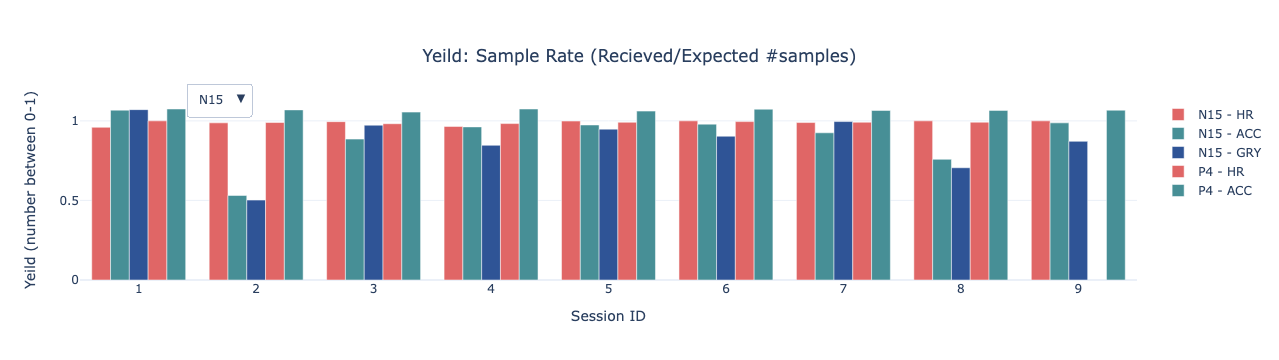

In [76]:
# Create figure
fig = go.Figure()

# Add traces for each participant
participants = df_yeild_gry['pid_list_yeild_gry: '].unique()
df_yeild_gry["int_session"] = df_yeild_gry["session_id_list_yeild_gry"].apply(convert_int_session)
df_acc_yeild["int_session"]  = df_acc_yeild["session_id_list_yeild"].apply(convert_int_session)
df_hr_yeild["int_session"] =  df_hr_yeild["session_id_list_yeild"].apply(convert_int_session)
for participant in participants:
    
    # Filter data for the current participant
    participant_data_gyro = df_yeild_gry[df_yeild_gry['pid_list_yeild_gry: '] == participant]
    participant_data_acc = df_acc_yeild[df_acc_yeild['pid_list_yeild: '] == participant]
    participant_data_hr = df_hr_yeild[df_hr_yeild['pid_list_yeild: '] == participant]
    
    grpup_average_yeild_gyro = participant_data_gyro.groupby("int_session")['yeild_gry_list'].mean()
    grpup_average_yeild_acc = participant_data_acc.groupby("int_session")["yeild_acc_list"].mean()
    grpup_average_yeild_hr = participant_data_hr.groupby("int_session")["yeild_hr_list"].mean()

    # Add traces for each component
#     fig.add_trace(
#         go.Bar(
#             x=group_avg.index,
#             y=participant_data["yeild_gry_list"],
#             name=f"{participant} - Mouse",
#             visible=False,
#             marker=dict(color="#e69138")
#         )
#     )
    fig.add_trace(
        go.Bar(
            x=grpup_average_yeild_hr.index,
            y=grpup_average_yeild_hr,
            name=f"{participant} - HR",
            visible=False,
            marker=dict(color="#e06666")
        )
    )
    fig.add_trace(
        go.Bar(
            x=grpup_average_yeild_acc.index,
            y=grpup_average_yeild_acc,
            name=f"{participant} - ACC",
            visible=False,
            marker=dict(color="#478f96")
        )
    )
    fig.add_trace(
        go.Bar(
            x=grpup_average_yeild_gyro.index,
            y=grpup_average_yeild_gyro,
            name=f"{participant} - GRY",
            visible=False,
            marker=dict(color="#2f5496")
        )
    )
#     fig.add_trace(
#         go.Bar(
#             x=participant_data["int_session"],
#             y=participant_data["number_files_list_level_info"],
#             name=f"{participant} - LEVEL INFO",
#             visible=False,
#             marker=dict(color="#a64d79")
#         )
#     )
# Make the first participant's traces visible by default
for i in range(5):  # Assuming 2 traces per participant (Mouse and HR)
    fig.data[i].visible = True

# Create dropdown menu
dropdown_buttons = []
for i, participant in enumerate(participants):
    # Set visibility: only the traces for the current participant should be visible
    visibility = [False] * len(fig.data)
    visibility[i * 3] = True  # Mouse trace
    visibility[i * 3 + 1] = True  # HR trace
    visibility[i * 3 + 2] = True  # ACC trace
#     visibility[i * 5 + 3] = True  # GRY trace
#     visibility[i * 5 + 4] = True  # LEVEL INFO trace


    
    dropdown_buttons.append(
        dict(
            label=participant,
            method="update",
            args=[
                {"visible": visibility},  # Update visibility
                #{"title": f"Participant {participant} Data"},  # Update title
            ]
        )
    )

# Add dropdown to layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top",
        )
    ],
        title=dict(
        text="Yeild: Sample Rate (Recieved/Expected #samples)",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Session ID"),
    yaxis=dict(title="Yeild (number between 0-1)"),
    template="plotly_white",   )

# Show the figure
fig.show()

In [77]:
df_yeild_gry.columns

Index(['pid_list_yeild_gry: ', 'session_id_list_yeild_gry',
       'filename_list_yeild_gry', 'yeild_gry_list', 'int_session'],
      dtype='object')

In [78]:
pid_15 = df_yeild_gry[df_yeild_gry['pid_list_yeild_gry: ']=="N15"]
at_home_session = pid_15[pid_15["int_session"]==1]
at_home_session

,pid_list_yeild_gry:,session_id_list_yeild_gry,filename_list_yeild_gry,yeild_gry_list,int_session
148,N15,Session_1_2024-06-19_PM,watch_N15_L1_S1_1718819326_gyroscope.csv,1.076190,1
149,N15,Session_1_2024-06-19_PM,watch_N15_L1_S2_1718819379_gyroscope.csv,1.096000,1
150,N15,Session_1_2024-06-19_PM,watch_N15_L1_S3_1718819407_gyroscope.csv,1.048000,1
151,N15,Session_1_2024-06-19_PM,watch_N15_L2_S1_1718819434_gyroscope.csv,1.104348,1
152,N15,Session_1_2024-06-19_PM,watch_N15_L2_S2_1718819461_gyroscope.csv,1.078261,1
153,N15,Session_1_2024-06-19_PM,watch_N15_L2_S3_1718819487_gyroscope.csv,1.075862,1
154,N15,Session_1_2024-06-19_PM,watch_N15_L3_S1_1718819519_gyroscope.csv,1.087179,1
155,N15,Session_1_2024-06-19_PM,watch_N15_L3_S2_1718819561_gyroscope.csv,1.063636,1
156,N15,Session_1_2024-06-19_PM,watch_N15_L3_S3_1718819589_gyroscope.csv,1.096296,1
157,N15,Session_1_2024-06-19_PM,watch_N15_L4_S1_1718819620_gyroscope.csv,1.057143,1


In [79]:
pid_15 = df_yeild_gry[df_yeild_gry['pid_list_yeild_gry: ']=="N15"]
pid_15[pid_15["int_session"]!=1]

,pid_list_yeild_gry:,session_id_list_yeild_gry,filename_list_yeild_gry,yeild_gry_list,int_session
0,N15,Session_9_2024-07-06_PM,watch_N15_L1_S1_1720305155_gyroscope.csv,0.859259,9
1,N15,Session_9_2024-07-06_PM,watch_N15_L1_S2_1720305166_gyroscope.csv,0.772222,9
2,N15,Session_9_2024-07-06_PM,watch_N15_L1_S3_1720305178_gyroscope.csv,0.825641,9
3,N15,Session_9_2024-07-06_PM,watch_N15_L2_S1_1720305192_gyroscope.csv,0.872222,9
4,N15,Session_9_2024-07-06_PM,watch_N15_L2_S2_1720305237_gyroscope.csv,0.811111,9
...,...,...,...,...,...
189,N15,Session_8_2024-07-06_PM,watch_N15_L10_S1_1720304083_gyroscope.csv,0.733333,8
190,N15,Session_8_2024-07-06_PM,watch_N15_L10_S1_1720304087_gyroscope.csv,0.400000,8
191,N15,Session_8_2024-07-06_PM,watch_N15_L10_S1_1720304088_gyroscope.csv,0.533333,8
192,N15,Session_8_2024-07-06_PM,watch_N15_L10_S1_1720304091_gyroscope.csv,0.666667,8


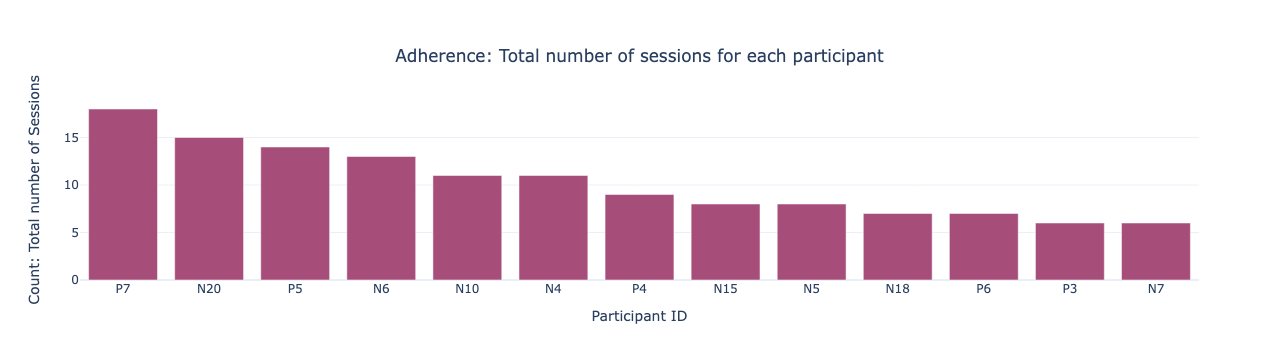

In [80]:
    
fig = go.Figure(data=[
#     go.Bar(name='Mouse',x=df_number_files_mouse["pid_list"].value_counts().index , y=df_number_files_mouse["pid_list"].value_counts(),marker=dict(color='#e69138')), #e69138
#     go.Bar(name='HR', x= df_number_files_hr['pid_list'].value_counts().index,y=df_number_files_hr['pid_list'].value_counts(),marker=dict(color='#e06666')),
#     go.Bar(name='Gryo',x=df_number_files_gry["pid_list"].value_counts().index, y=df_number_files_gry["pid_list"].value_counts(),marker=dict(color='#2f5496')),
#     go.Bar(name='Acc', x=df_number_files_gry["pid_list"].value_counts().index,y=df_number_files_acc["pid_list"].value_counts(),marker=dict(color='#478f96')),
    go.Bar(name='Level_info', x=df_number_of_files_levels_info["pid_list"].value_counts().index,y=df_number_of_files_levels_info["pid_list"].value_counts(),marker=dict(color='#a64d79')),
])

# Change the bar mode
fig.update_layout(barmode='group')

# Add dropdown to layout
fig.update_layout(
        title=dict(
        text="Adherence: Total number of sessions for each participant",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID "),
    yaxis=dict(title="Count: Total number of Sessions"),
    template="plotly_white",
)
fig.show()


In [81]:
subset_df_levels_info_ADHD = df_number_of_files_levels_info[df_number_of_files_levels_info['pid_list'].str.startswith('P')]
subset_df_levels_info_ADHD = subset_df_levels_info_ADHD.sort_values(by='pid_list')

subset_df_levels_info_ADHD['numericID'] = subset_df_levels_info_ADHD['pid_list'].str.replace('P', '', regex=False)
subset_df_levels_info_ADHD

,number_files_list_level_info,pid_list,session_id_list,numericID
18,19,P3,Session_3_2024-06-14_AM,3
22,18,P3,Session_4_2024-06-15_PM,3
21,19,P3,Session_6_2024-06-17_PM,3
20,9,P3,Session_5_2024-06-16_PM,3
19,18,P3,Session_1_2024-05-29_AM,3
17,13,P3,Session_2_2024-06-11_AM,3
16,18,P4,Session_7_2024-06-04_PM,4
8,14,P4,Session_4_2024-06-02_PM,4
14,12,P4,Session_6_2024-06-03_PM,4
13,16,P4,Session_3_2024-06-01_PM,4


In [82]:
subset_df_levels_info_Neurotypical = df_number_of_files_levels_info[df_number_of_files_levels_info['pid_list'].str.startswith('N')]

subset_df_levels_info_Neurotypical['numericID'] = subset_df_levels_info_Neurotypical['pid_list'].str.replace('N', '', regex=False).astype(int)


subset_df_levels_info_Neurotypical["numericID"].unique()



/Users/shehjarsadhu/opt/anaconda3/envs/carehub/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



array([15,  7,  6, 18, 20, 10,  4,  5])

In [83]:
subset_df_levels_info_Neurotypical = subset_df_levels_info_Neurotypical.sort_values(by='numericID')

subset_df_levels_info_Neurotypical

,number_files_list_level_info,pid_list,session_id_list,numericID
115,19,N4,Session_2_2024-06-10_PM,4
123,18,N4,Session_1_2024-05-29_AM,4
122,21,N4,Session_4_2024-06-11_PM,4
121,19,N4,Session_10_2024-06-16_PM,4
120,18,N4,Session_6_2024-06-12_PM,4
...,...,...,...,...
91,10,N20,Session_12_2024-07-30_AM,20
92,18,N20,Session_1_2024-06-18_PM,20
93,20,N20,Session_8_2024-07-02_AM,20
95,17,N20,Session_14_2024-08-01_AM,20


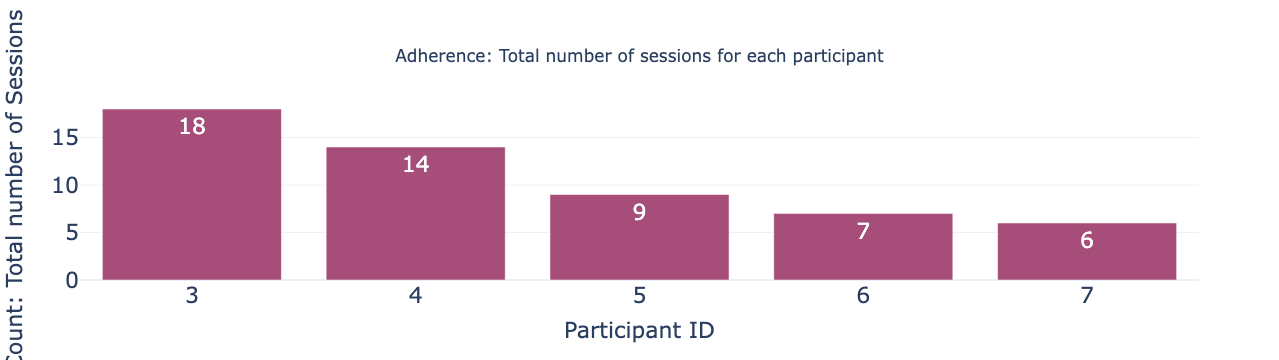

In [84]:
    
fig = go.Figure(data=[
    go.Bar(name='Level_info', x=subset_df_levels_info_ADHD["numericID"].value_counts().sort_index().index,
           y=subset_df_levels_info_ADHD["pid_list"].value_counts(),
           text=subset_df_levels_info_ADHD["pid_list"].value_counts().values,  # Add text on top of the bars
            textposition='inside',  # Position text outside the bars
                       textfont=dict(size=22),  # Set the text font size

                       marker=dict(color='#a64d79')),
])

# Change the bar mode
fig.update_layout(barmode='group')

# Add dropdown to layout
fig.update_layout(
        title=dict(
        text="Adherence: Total number of sessions for each participant",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    yaxis=dict(title="Count: Total number of Sessions",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    template="plotly_white",
)
fig.show()


In [85]:
subset_df_levels_info_Neurotypical["numericID"].value_counts().sort_index().index.to_list()

[4, 5, 6, 7, 10, 15, 18, 20]

In [86]:

# Creating a DataFrame for cleaner handling
data = pd.DataFrame({'X': subset_df_levels_info_Neurotypical["numericID"].value_counts().sort_index().index.to_list(),
                     'Y': subset_df_levels_info_Neurotypical["numericID"].value_counts().sort_index().values})
# Filter out missing values explicitly
data = data.dropna()
# Sorting the data (optional, if your indices aren't already sorted)
data = data.sort_values(by='X')


In [87]:
data

,X,Y
0,4,11
1,5,8
2,6,13
3,7,6
4,10,11
5,15,8
6,18,7
7,20,15


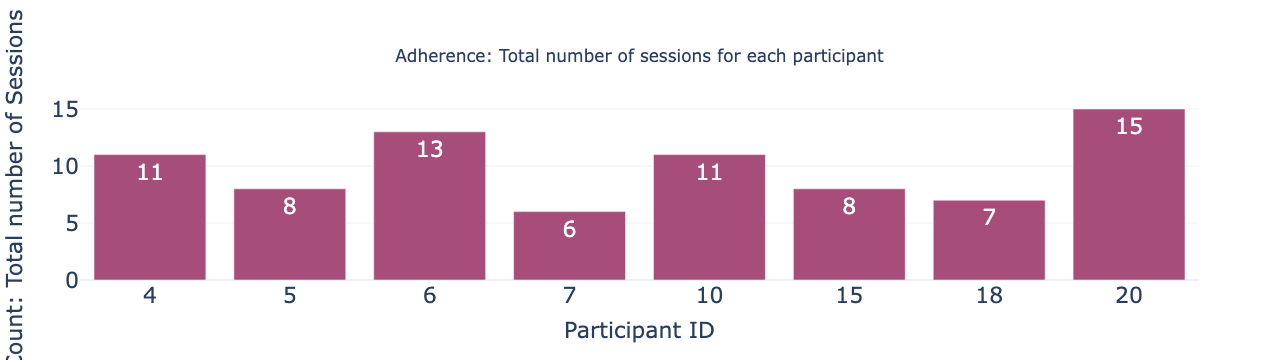

In [88]:
    
fig2 = go.Figure(data=[
    go.Bar(name='Level_info',
           x=data["X"].astype(str),
           y=data["Y"],
           text=data["Y"].values,  # Add text on top of the bars
           textposition='inside',  # Position text outside the bars
            textfont=dict(size=22),  # Set the text font size

           marker=dict(color='#a64d79')
          )])

# Change the bar mode.
fig2.update_layout(
    barmode='group'
)

# Add dropdown to layout.
fig2.update_layout(
        title=dict(
        text="Adherence: Total number of sessions for each participant",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID ",
            titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="Count: Total number of Sessions",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    template="plotly_white",
)
fig2.show()


In [89]:
yeild_gry_df_inlab  = df_yeild_gry[df_yeild_gry["int_session"]==1]
yeild_gry_df_in_home  = df_yeild_gry[df_yeild_gry["int_session"]!=1]
grouped_avg_yeild_gry_inlab = yeild_gry_df_inlab.groupby('pid_list_yeild_gry: ')['yeild_gry_list'].mean()
grouped_avg_yeild_gry_in_home = yeild_gry_df_in_home.groupby('pid_list_yeild_gry: ')['yeild_gry_list'].mean()



In [90]:
df_acc_yeild.columns

Index(['pid_list_yeild: ', 'session_id_list_yeild', 'filename_list_yeild',
       'yeild_acc_list', 'int_session'],
      dtype='object')

In [91]:
df_snr_acc.columns

Index(['snr_acc_x_list', 'snr_acc_y_list', 'snr_acc_z_list', 'pid',
       'SessionID'],
      dtype='object')

In [92]:
df_number_files_hr.columns

Index(['pid_list', 'session_id_list', 'number_files_list_hr'], dtype='object')

In [93]:
################################### Prepare Number of Files Data for HR in-lab vs in-home ############################.
df_number_files_hr["int_session"] = df_number_files_hr["session_id_list"].apply(convert_int_session)

number_of_files_df_inlab_hr  = df_number_files_hr[df_number_files_hr["int_session"]==1]
number_of_files_df_inhome_hr  = df_number_files_hr[df_number_files_hr["int_session"]!=1]


grouped_sum_snr_HR_inlab = number_of_files_df_inlab_hr.groupby('pid_list')['number_files_list_hr'].sum()
grouped_sum_snr_HR_in_home = number_of_files_df_inhome_hr.groupby('pid_list')['number_files_list_hr'].sum()

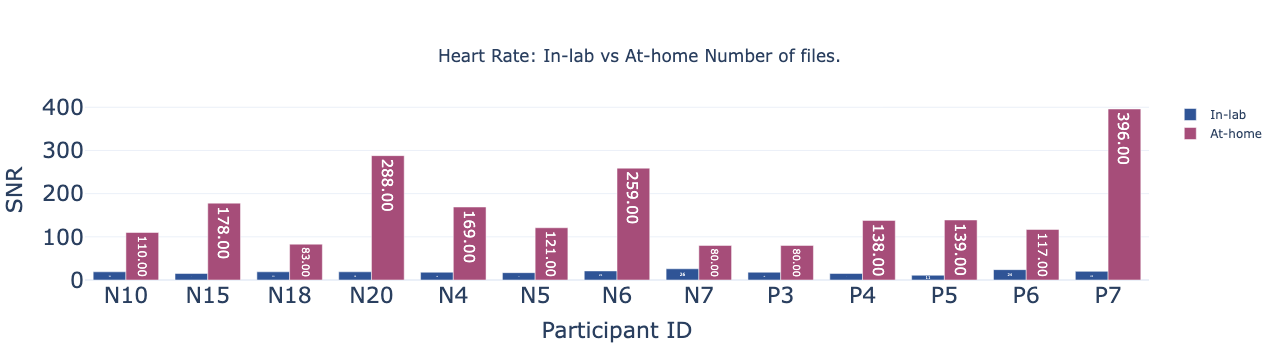

In [94]:
fig7 = go.Figure([go.Bar(x=grouped_sum_snr_HR_inlab.index ,
                         y=grouped_sum_snr_HR_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_sum_snr_HR_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_sum_snr_HR_in_home.index,
                        y=grouped_sum_snr_HR_in_home,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_sum_snr_HR_in_home],
                        textposition='inside',
                        textfont=dict(size=15),) ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig7.update_layout(
        title=dict(
        text="Heart Rate: In-lab vs At-home Number of files.",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
            titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="SNR",
               titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    template="plotly_white")

# Show the figure
fig7.show()

In [95]:
################################### Prepare SNR Data for Accelerometer in-lab vs in-home ############################.
df_snr_acc["int_session"] = df_snr_acc["SessionID"].apply(convert_int_session)

snr_acc_df_inlab  = df_snr_acc[df_snr_acc["int_session"]==1]
snr_acc_df_in_home  = df_snr_acc[df_snr_acc["int_session"]!=1]

grouped_avg_snr_acc_x_inlab = snr_acc_df_inlab.groupby('pid')['snr_acc_x_list'].mean()
grouped_avg_snr_acc_x_in_home = snr_acc_df_in_home.groupby('pid')['snr_acc_x_list'].mean()

grouped_avg_snr_acc_y_inlab = snr_acc_df_inlab.groupby('pid')['snr_acc_y_list'].mean()
grouped_avg_snr_acc_y_in_home = snr_acc_df_in_home.groupby('pid')['snr_acc_y_list'].mean()

grouped_avg_snr_acc_z_inlab = snr_acc_df_inlab.groupby('pid')['snr_acc_z_list'].mean()
grouped_avg_snr_acc_z_in_home = snr_acc_df_in_home.groupby('pid')['snr_acc_z_list'].mean()




In [96]:
df_snr_gry.columns

NameError: name 'df_snr_gry' is not defined

In [97]:
# df_snr_gry

################################### Prepare SNR Data for Gyroscope in-lab vs in-home ############################.
df_snr_gry["int_session"] = df_snr_gry["sessionID_list"].apply(convert_int_session)

snr_gyr_df_inlab  = df_snr_gry[df_snr_gry["int_session"]==1]
snr_gyr_df_in_home  = df_snr_gry[df_snr_gry["int_session"]!=1]

grouped_avg_snr_acc_x_inlab = snr_gyr_df_inlab.groupby('pid_list_file_name')['snr_gyr_x_list'].mean()
grouped_avg_snr_acc_x_in_home = snr_gyr_df_in_home.groupby('pid_list_file_name')['snr_gyr_x_list'].mean()

grouped_avg_snr_acc_y_inlab = snr_gyr_df_inlab.groupby('pid_list_file_name')['snr_gyr_y_list'].mean()
grouped_avg_snr_acc_y_in_home = snr_gyr_df_in_home.groupby('pid_list_file_name')['snr_gyr_y_list'].mean()

grouped_avg_snr_acc_z_inlab = snr_gyr_df_inlab.groupby('pid_list_file_name')['snr_gyr_z_list'].mean()
grouped_avg_snr_acc_z_in_home = snr_gyr_df_in_home.groupby('pid_list_file_name')['snr_gyr_z_list'].mean()




NameError: name 'df_snr_gry' is not defined

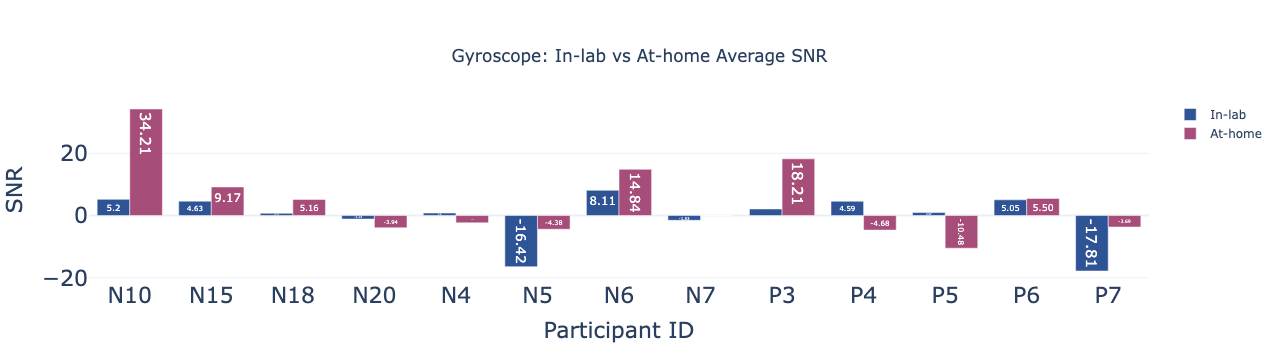

In [98]:
fig6 = go.Figure([go.Bar(x=grouped_avg_snr_acc_x_inlab.index ,
                         y=grouped_avg_snr_acc_x_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_snr_acc_x_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_avg_snr_acc_x_in_home.index,
                        y=grouped_avg_snr_acc_x_in_home,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_avg_snr_acc_x_in_home],
                        textposition='inside',
                        textfont=dict(size=15),) ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig6.update_layout(
        title=dict(
        text="Gyroscope: In-lab vs At-home Average SNR",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
            titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="SNR",
               titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    template="plotly_white")

# Show the figure
fig6.show()

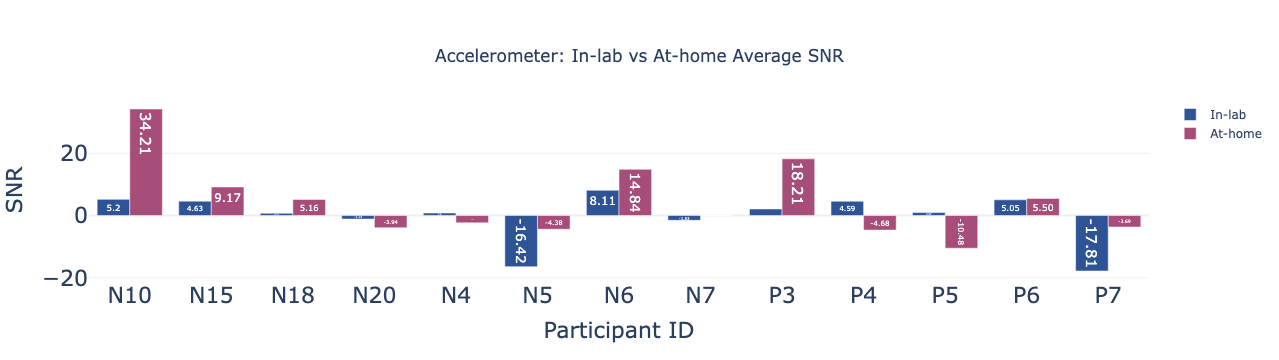

In [99]:
fig5 = go.Figure([go.Bar(x=grouped_avg_snr_acc_x_inlab.index ,
                         y=grouped_avg_snr_acc_x_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_snr_acc_x_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_avg_snr_acc_x_in_home.index,
                        y=grouped_avg_snr_acc_x_in_home,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_avg_snr_acc_x_in_home],
                        textposition='inside',
                        textfont=dict(size=15),) ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig5.update_layout(
        title=dict(
        text="Accelerometer: In-lab vs At-home Average SNR",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
            titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="SNR",
               titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    template="plotly_white")

# Show the figure
fig5.show()

In [100]:
yeild_acc_df_inlab  = df_acc_yeild[df_acc_yeild["int_session"]==1]
yeild_acc_df_in_home  = df_acc_yeild[df_acc_yeild["int_session"]!=1]
grouped_avg_yeild_acc_inlab = yeild_acc_df_inlab.groupby('pid_list_yeild: ')['yeild_acc_list'].mean()
grouped_avg_yeild_acc_in_home = yeild_acc_df_in_home.groupby('pid_list_yeild: ')['yeild_acc_list'].mean()



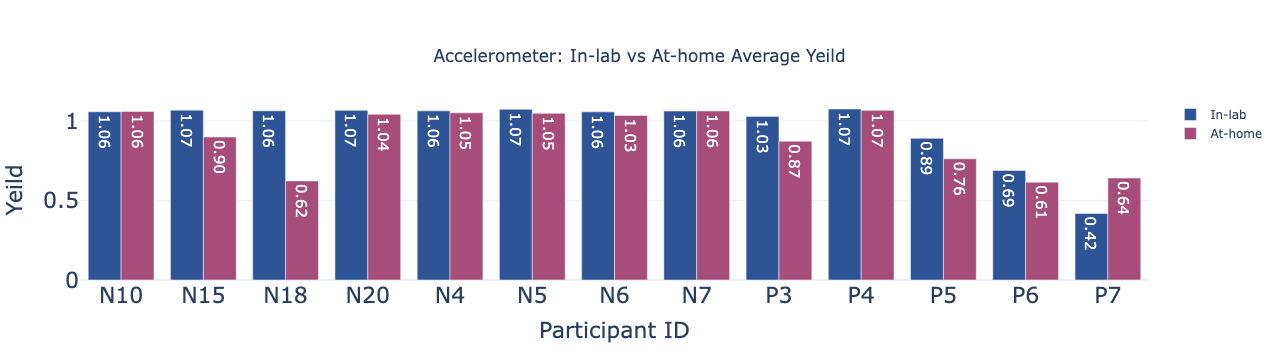

In [101]:
fig4 = go.Figure([go.Bar(x=grouped_avg_yeild_acc_inlab.index ,
                         y=grouped_avg_yeild_acc_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_yeild_acc_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_avg_yeild_acc_in_home.index,
                        y=grouped_avg_yeild_acc_in_home,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_avg_yeild_acc_in_home],
                        textposition='inside',
                        textfont=dict(size=15),
                    )
                 
                 ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig4.update_layout(
        title=dict(
        text="Accelerometer: In-lab vs At-home Average Yeild",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
            titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="Yeild",
               titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    template="plotly_white")

# Show the figure
fig4.show()

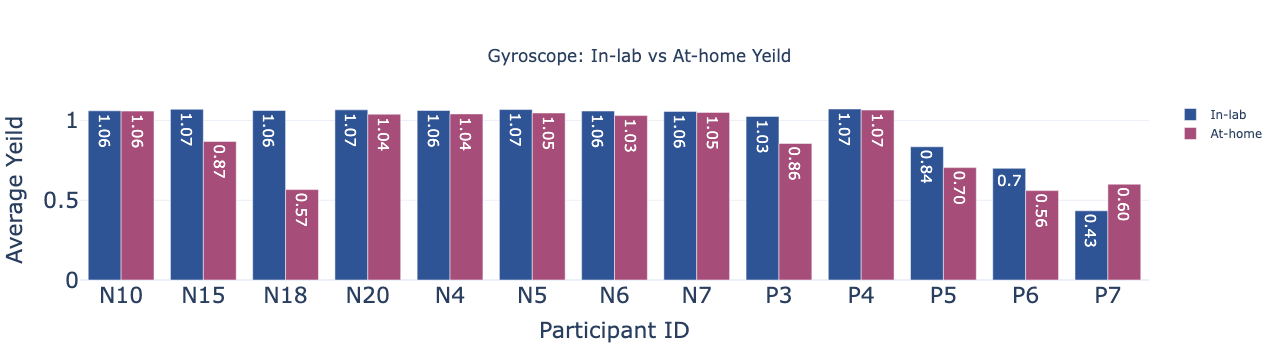

In [102]:
fig3 = go.Figure([go.Bar(x=grouped_avg_yeild_gry_inlab.index ,
                         y=grouped_avg_yeild_gry_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_yeild_gry_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_avg_yeild_gry_in_home.index,
                        y=grouped_avg_yeild_gry_in_home,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_avg_yeild_gry_in_home],
                        textposition='inside',
                        textfont=dict(size=15),
                    )
                 
                 ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig3.update_layout(
        title=dict(
        text="Gyroscope: In-lab vs At-home Yeild",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="Average Yeild",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    template="plotly_white")

# Show the figure
fig3.show()

In [103]:
yeild_gry_df_inlab.columns

Index(['pid_list_yeild_gry: ', 'session_id_list_yeild_gry',
       'filename_list_yeild_gry', 'yeild_gry_list', 'int_session'],
      dtype='object')

In [104]:
percentage_0s_df_hr["int_session"] = percentage_0s_df_hr["sessionID_list"].apply(convert_int_session)
percentage_0s_df_hr

,percentage_0s,sessionID_list,pid_list_file_name,int_session
0,0.0,Session_9_2024-07-06_PM,N15,9
1,0.0,Session_9_2024-07-06_PM,N15,9
2,0.0,Session_9_2024-07-06_PM,N15,9
3,0.0,Session_9_2024-07-06_PM,N15,9
4,0.0,Session_9_2024-07-06_PM,N15,9
...,...,...,...,...
2395,0.0,Session_5_2024-06-12_PM,N5,5
2396,0.0,Session_5_2024-06-12_PM,N5,5
2397,0.0,Session_5_2024-06-12_PM,N5,5
2398,0.0,Session_5_2024-06-12_PM,N5,5


In [105]:
in_lab_percentage_0s_df = percentage_0s_df_hr[percentage_0s_df_hr["int_session"]==1]
in_lab_percentage_0s_df

,percentage_0s,sessionID_list,pid_list_file_name,int_session
148,0.000000,Session_1_2024-06-19_PM,N15,1
149,0.000000,Session_1_2024-06-19_PM,N15,1
150,0.000000,Session_1_2024-06-19_PM,N15,1
151,0.000000,Session_1_2024-06-19_PM,N15,1
152,0.000000,Session_1_2024-06-19_PM,N15,1
...,...,...,...,...
2347,0.231481,Session_1_2024-05-29_PM,N5,1
2348,0.000000,Session_1_2024-05-29_PM,N5,1
2349,0.000000,Session_1_2024-05-29_PM,N5,1
2350,0.000000,Session_1_2024-05-29_PM,N5,1


In [106]:
grouped_avg_percentage_0_hr_inlab = in_lab_percentage_0s_df.groupby('pid_list_file_name')['percentage_0s'].mean()
grouped_avg_percentage_0_hr_inlab

pid_list_file_name
N10    0.062024
N15    0.617284
N18    0.000000
N20    0.041771
N4     0.296262
N5     0.054466
N6     0.044092
N7     0.377493
P3     1.622575
P4     0.072751
P5     0.000000
P6     0.000000
P7     0.166667
Name: percentage_0s, dtype: float64

In [107]:
at_home_percentage_0s_df = percentage_0s_df_hr[percentage_0s_df_hr["int_session"]!=1]
at_home_percentage_0s_df

,percentage_0s,sessionID_list,pid_list_file_name,int_session
0,0.0,Session_9_2024-07-06_PM,N15,9
1,0.0,Session_9_2024-07-06_PM,N15,9
2,0.0,Session_9_2024-07-06_PM,N15,9
3,0.0,Session_9_2024-07-06_PM,N15,9
4,0.0,Session_9_2024-07-06_PM,N15,9
...,...,...,...,...
2395,0.0,Session_5_2024-06-12_PM,N5,5
2396,0.0,Session_5_2024-06-12_PM,N5,5
2397,0.0,Session_5_2024-06-12_PM,N5,5
2398,0.0,Session_5_2024-06-12_PM,N5,5


In [108]:
grouped_avg_percentage_0_hr_athome = at_home_percentage_0s_df.groupby('pid_list_file_name')['percentage_0s'].mean()
grouped_avg_percentage_0_hr_athome

pid_list_file_name
N10    0.389842
N15    0.098174
N18    0.082755
N20    0.218406
N4     0.139508
N5     0.596820
N6     0.067797
N7     0.099868
P3     0.235324
P4     1.037695
P5     0.227318
P6     0.063594
P7     0.485642
Name: percentage_0s, dtype: float64

In [109]:
df_hr_yeild.columns

Index(['pid_list_yeild: ', 'session_id_list_yeild', 'filename_list_yeild',
       'yeild_hr_list', 'int_session'],
      dtype='object')

In [110]:

yeild_hr_df_inlab  = df_hr_yeild[df_hr_yeild["int_session"]==1]
yeild_hr_df_in_home  = df_hr_yeild[df_hr_yeild["int_session"]!=1]

################################################################################################################
grouped_avg_yeild_hr_inlab = yeild_hr_df_inlab.groupby('pid_list_yeild: ')['yeild_hr_list'].mean()
grouped_avg_yeild_hr_in_home = yeild_hr_df_in_home.groupby('pid_list_yeild: ')['yeild_hr_list'].mean()
grouped_avg_yeild_hr_in_home


pid_list_yeild: 
N10    0.993414
N15    0.991217
N18    0.980641
N20    0.986609
N4     0.994310
N5     0.996562
N6     0.992367
N7     0.996555
P3     0.969462
P4     0.989782
P5     0.993398
P6     0.992057
P7     0.992675
Name: yeild_hr_list, dtype: float64

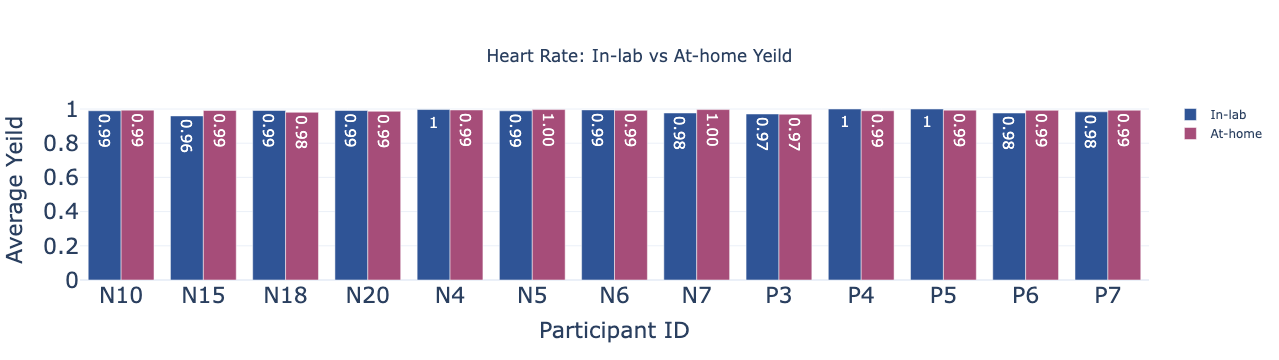

In [111]:
fig4 = go.Figure([go.Bar(x=grouped_avg_yeild_hr_inlab.index ,
                         y=grouped_avg_yeild_hr_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_yeild_hr_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_avg_yeild_hr_in_home.index,
                        y=grouped_avg_yeild_hr_in_home,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_avg_yeild_hr_in_home],
                        textposition='inside',
                        textfont=dict(size=15),)
                 ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig4.update_layout(
        title=dict(
        text="Heart Rate: In-lab vs At-home Yeild",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    yaxis=dict(title="Average Yeild",
                          titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size

              ),
    template="plotly_white")

# Show the figure
fig4.show()

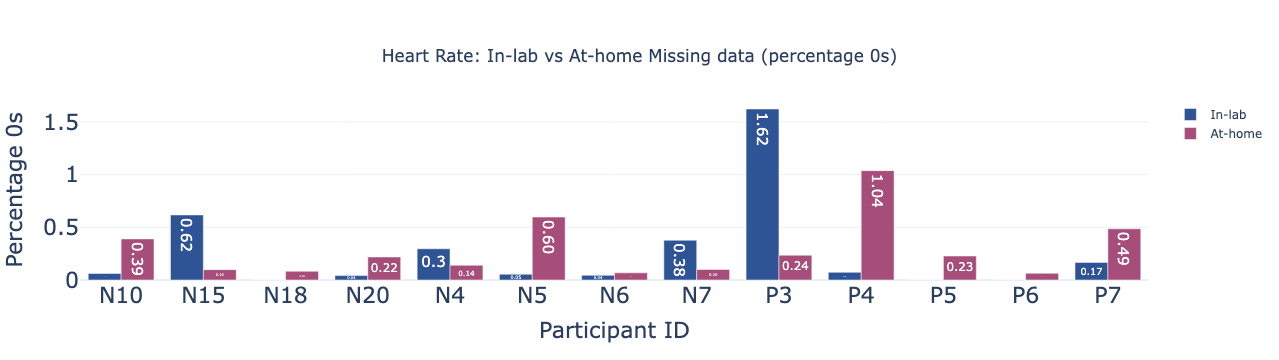

In [112]:
fig3 = go.Figure([go.Bar(x=grouped_avg_percentage_0_hr_inlab.index ,
                         y=grouped_avg_percentage_0_hr_inlab,
                         name="In-lab",
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_percentage_0_hr_inlab.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15)),
                    go.Bar(
                        x=grouped_avg_percentage_0_hr_athome.index,
                        y=grouped_avg_percentage_0_hr_athome,
                        name="At-home",
                        marker=dict(color='#a64d79'),
                        text=[f"{val:.2f}" for val in grouped_avg_percentage_0_hr_athome],
                        textposition='inside',
                        textfont=dict(size=15),
                    )
                 
                 ]) # Set the font size for the text 
                        

# Add dropdown to layout
fig3.update_layout(
        title=dict(
        text="Heart Rate: In-lab vs At-home Missing data (percentage 0s)",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID",
               titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    yaxis=dict(title="Percentage 0s",
               titlefont=dict(size=22),  # Set x-axis title font size
            tickfont=dict(size=22)  # Set x-axis tick font size
              ),
    template="plotly_white")

# Show the figure
fig3.show()

In [113]:
# Group by 'Group' column and calculate the average of 'Value'
grouped_avg_percentage_0_hr = percentage_0s_df_hr.groupby('pid_list_file_name')['percentage_0s'].mean()
grouped_avg_percentage_0_hr

pid_list_file_name
N10    0.341559
N15    0.138520
N18    0.067340
N20    0.207474
N4     0.154596
N5     0.530009
N6     0.066019
N7     0.167964
P3     0.490125
P4     0.943092
P5     0.210648
P6     0.052769
P7     0.470307
Name: percentage_0s, dtype: float64

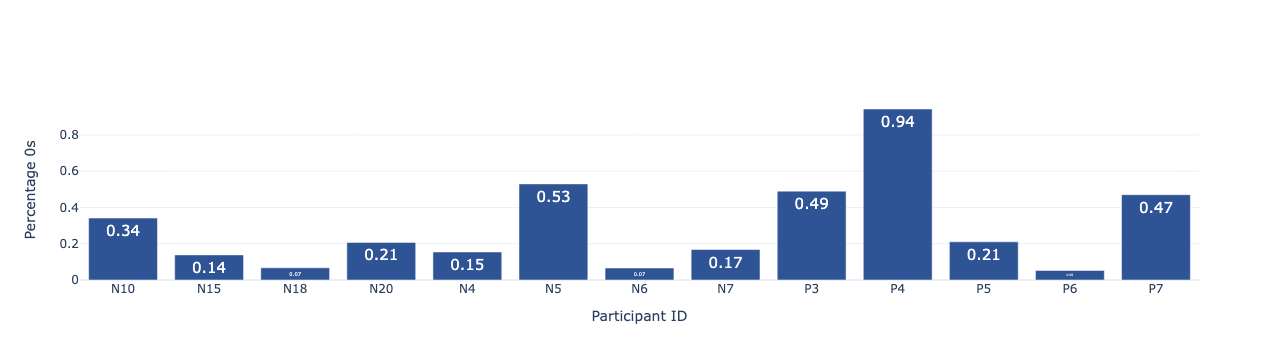

In [114]:
fig3 = go.Figure([go.Bar(x=grouped_avg_percentage_0_hr.index ,
                         y=grouped_avg_percentage_0_hr,
                         marker=dict(color='#2f5496'),
                        text=grouped_avg_percentage_0_hr.round(2),  # Add rounded text annotations
                        textposition='inside',  # Position the text above the bars
                        textfont=dict(size=15) )]) # Set the font size for the text 
                        

# Add dropdown to layout
fig3.update_layout(
        title=dict(
        text="",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top",  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Participant ID"),
    yaxis=dict(title="Percentage 0s"),
    template="plotly_white")

# Show the figure
fig3.show()

In [119]:


# Function to update the plot based on selected participant, session, and filename
def update_plot(participant, session, filename):
    filtered_df = percentage_0s_df_hr[
        (percentage_0s_df_hr["pid_list_file_name"] == participant) &
        (percentage_0s_df_hr["sessionID_list"] == session) 
    ]
    
    # Create the line plot
    fig = go.Figure()
        # Add traces for each component
    fig.add_trace(
        go.Bar(
#             x=participant_data["int_session"],
            y=percentage_0s_df_hr["percentage_0s"],
            name=f"{participant} - Mouse",
            visible=False,
            marker=dict(color="#e69138")
        )
    )
    fig.show()

# Dynamic update for session and filename based on selected participant
def create_widgets(participant_id):
    sessions = percentage_0s_df_hr[percentage_0s_df_hr["pid_list_file_name"] == participant_id]["sessionID_list"].unique()
    session_widget = Dropdown(options=sessions, description='Session:')
    
    def update_filename_widget(session_id):
        filenames = percentage_0s_df_hr[
            (percentage_0s_df_hr["pid_list_file_name"] == participant_id) &
            (percentage_0s_df_hr["sessionID_list"] == session_id)
        ]["pid_list_file_name"].unique()
        
        filename_widget = Dropdown(options=filenames, description='Filename:')
        interact(update_plot, participant=participant_id, session=session_id, filename=filename_widget)
    
    interact(update_filename_widget, session_id=session_widget)

# Participant Dropdown
participants = percentage_0s_df_hr["pid_list_file_name"].unique()
participant_widget = Dropdown(options=participants, description='Participant:')
interact(create_widgets, participant_id=participant_widget)


interactive(children=(Dropdown(description='Participant:', options=('N15', 'P4', 'P3', 'P5', 'N7', 'N6', 'P7',…

<function __main__.create_widgets(participant_id)>

In [120]:
df_hr_yeild

,pid_list_yeild:,session_id_list_yeild,filename_list_yeild,yeild_hr_list,int_session
0,N15,Session_9_2024-07-06_PM,watch_N15_L1_S1_1720305155_heartrate.csv,1.0,9
1,N15,Session_9_2024-07-06_PM,watch_N15_L1_S2_1720305166_heartrate.csv,1.0,9
2,N15,Session_9_2024-07-06_PM,watch_N15_L1_S3_1720305178_heartrate.csv,1.0,9
3,N15,Session_9_2024-07-06_PM,watch_N15_L2_S1_1720305192_heartrate.csv,1.0,9
4,N15,Session_9_2024-07-06_PM,watch_N15_L2_S2_1720305237_heartrate.csv,1.0,9
...,...,...,...,...,...
2380,N5,Session_5_2024-06-12_PM,watch_N5_L5_S2_1718215959_heartrate.csv,1.0,5
2381,N5,Session_5_2024-06-12_PM,watch_N5_L5_S3_1718216004_heartrate.csv,1.0,5
2382,N5,Session_5_2024-06-12_PM,watch_N5_L6_S1_1718216045_heartrate.csv,1.0,5
2383,N5,Session_5_2024-06-12_PM,watch_N5_L6_S2_1718216086_heartrate.csv,1.0,5


In [121]:


grouped_avg_percentage_missing = percentage_missing_df.groupby('pid_list_file_name')['percentage_missing_list'].mean()
formatted_text = [f"{val:.2f}%" for val in grouped_avg_percentage_missing]

grouped_avg_percentage_missing

pid_list_file_name
N10     0.351084
N15     9.306313
N18    20.434763
N20     0.708600
N4      1.154999
N5      1.822987
N6      1.023682
N7     -0.129042
P3     12.345867
P4     -0.050263
P5     25.374283
P6     26.367990
P7     24.784898
Name: percentage_missing_list, dtype: float64

In [122]:
grouped_avg_percentage_missing

pid_list_file_name
N10     0.351084
N15     9.306313
N18    20.434763
N20     0.708600
N4      1.154999
N5      1.822987
N6      1.023682
N7     -0.129042
P3     12.345867
P4     -0.050263
P5     25.374283
P6     26.367990
P7     24.784898
Name: percentage_missing_list, dtype: float64

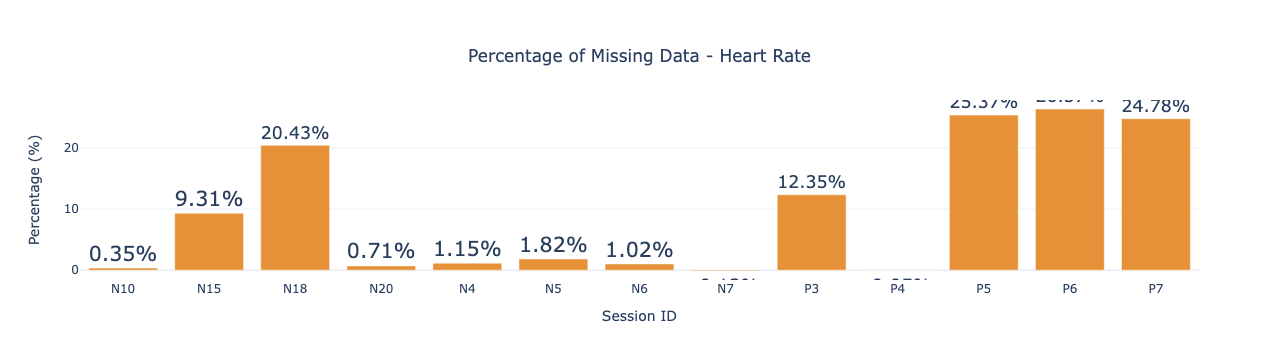

In [123]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=grouped_avg_percentage_missing.index,
        y=grouped_avg_percentage_missing,
        name="Percentage (%)",
        marker=dict(color="#e69138"),
        text=formatted_text,  # Add formatted text
        textposition="outside",  # Position text outside the bars
        textfont=dict(size=28),  # Increase font size of the text
    )
)
# Add dropdown to layout
fig.update_layout(
    title=dict(
    text="Percentage of Missing Data - Heart Rate",
    x=0.5,  # Center the title
    xanchor="center",  # Anchor the title at its center
    yanchor="top"  # Optional: Anchor the title at the top
),
    xaxis=dict(title="Session ID"),
    yaxis=dict(title="Percentage (%)"),
    template="plotly_white",
)
fig.show()

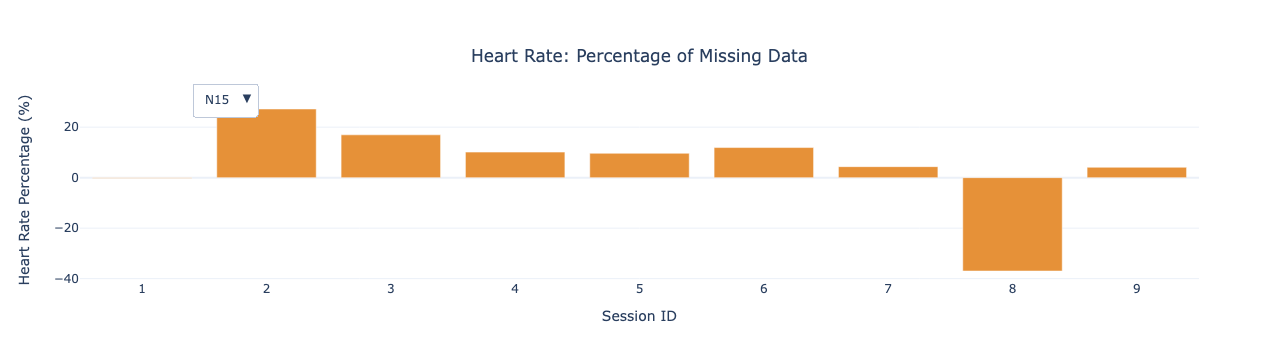

In [124]:
# Create figure
fig = go.Figure()

#Convert_session_id(session_id_str) Session_5_2024-06-12_PM to 5.
percentage_missing_df["int_session"] = percentage_missing_df["sessionID_list"].apply(convert_session_id) 

# Add traces for each participant
participants = percentage_missing_df["pid_list_file_name"].unique()
for participant in participants:
    # Filter data for the current participant
    participant_data = percentage_missing_df[percentage_missing_df["pid_list_file_name"] == participant]
    # Average of each puzzle in each session.
    grouped_avg_percentage_missing_pid = participant_data.groupby('int_session')['percentage_missing_list'].mean()
    #print("grouped_avg_percentage_missing_pid: ",grouped_avg_percentage_missing_pid)
    #print("participant_data : ",participant_data["pid_list_file_name"].unique())
    # Add traces for each component
    fig.add_trace(
        go.Bar(
            x=grouped_avg_percentage_missing_pid.index,
            y=grouped_avg_percentage_missing_pid,
            name=f"{participant} - Percentage (%)",
            visible=False,
            marker=dict(color="#e69138")
        )
    )
# Make the first participant's traces visible by default
for i in range(1):  # Assuming 2 traces per participant (Mouse and HR)
    fig.data[i].visible = True

# Create dropdown menu
dropdown_buttons = []
for i, participant in enumerate(participants):
    # Set visibility: only the traces for the current participant should be visible
    visibility = [False] * len(fig.data)
    visibility[i * 1] = True 
    dropdown_buttons.append(
        dict(
            label=participant,
            method="update",
            args=[
                {"visible": visibility},  # Update visibility
            ]
        )
    )

# Add dropdown to layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=dropdown_buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.15,
            yanchor="top",
        )
    ],
        title=dict(
        text="Heart Rate: Percentage of Missing Data",
        x=0.5,  # Center the title
        xanchor="center",  # Anchor the title at its center
        yanchor="top"  # Optional: Anchor the title at the top
    ),
    xaxis=dict(title="Session ID"),
    yaxis=dict(title="Heart Rate Percentage (%)"),
    template="plotly_white",
)
# Show the figure
fig.show()

In [125]:
df_mouse_entire

,x,y,timestamp,shape,x(px/s^2),y(px/s^2),PID,sessionID,filename
0,1170,922,1900-01-01 00:28:00.092,NaN,0,0,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
1,1160,870,1900-01-01 00:28:00.365,NaN,-74,-82,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
2,526,542,1900-01-01 00:28:00.565,NaN,-1456,-1844,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
3,364,203,1900-01-01 00:28:00.765,NaN,-230,-679,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
4,348,40,1900-01-01 00:28:00.965,NaN,153,-388,N15,Session_6_2024-07-05_AM,mouse_N15_L1_S1_1720153680.csv
...,...,...,...,...,...,...,...,...,...
344512,122,96,1900-01-01 19:17:12.714,Equilateral Triangle,34,25,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344513,709,268,1900-01-01 19:17:12.919,Equilateral Triangle,409,0,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344514,805,247,1900-01-01 19:17:13.130,Equilateral Triangle,20,-30,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv
344515,850,235,1900-01-01 19:17:13.339,Equilateral Triangle,-1250,230,N5,Session_5_2024-06-12_PM,mouse_N5_L6_S3_1718234199.csv


In [126]:
for i in df_mouse_entire["PID"].unique():
    df_mouse_subset_pid = df_mouse_entire[df_mouse_entire["PID"]==i]
    print("==================================================")
    print(df_mouse_subset_pid)

          x    y               timestamp                 shape      x(px/s^2)  \
0      1170  922 1900-01-01 00:28:00.092                   NaN              0   
1      1160  870 1900-01-01 00:28:00.365                   NaN            -74   
2       526  542 1900-01-01 00:28:00.565                   NaN          -1456   
3       364  203 1900-01-01 00:28:00.765                   NaN           -230   
4       348   40 1900-01-01 00:28:00.965                   NaN            153   
...     ...  ...                     ...                   ...            ...   
23663   145   65 1900-01-01 18:42:55.995                   NaN           -536   
23664   219  113 1900-01-01 18:42:56.195  Equilateral Triangle           1659   
23665  1658  377 1900-01-01 18:42:56.395  Equilateral Triangle           1731   
23666  1669  419 1900-01-01 18:42:56.595  Equilateral Triangle            -72   
23667  1658  421 1900-01-01 18:42:56.657         END_OF_STROKE  END_OF_STROKE   

           y(px/s^2)  PID  